# Active Authentication Pipeline v4 — Google Colab

Kiến trúc 2 tầng: **CNN 1D backbone** (inertial) + **Random Forest** (touch) + **score-level fusion**.

## Thay đổi từ v3 → v4
- **`min_samples_leaf`** cho RF (2 cho inertial, 1 cho touch) → tránh tree overfit 1 sample
- **Retry catastrophic runs** trong main.py: phát hiện AUC touch ≤ 0.55 hoặc FRR ≥ 0.5 → retry với seed mới
- **`N_RUNS = 10`** (was 5) → giảm variance trung bình
- **Median reporting** thêm vào mean ± std → robust với run-tệ
- **Logging exception đầy đủ** trong inner loop (không silent skip nữa)

## Bản FIXED — patch ngày `2026-05-18`
- **Sửa escape quote bị hỏng trong `config.py`** — bản gốc có `BACKBONE_ARCH = \\'cnn\\'` không phải Python hợp lệ → `%%writefile` ghi nguyên xi → mọi `import config` ở các cell sau crash với `SyntaxError`. Đây là lỗi block-pipeline nghiêm trọng nhất.
- Sửa `input_shape` metadata: dùng `WINDOW_SIZE` thay vì hard-code 100 — fix shape mismatch khi deploy Android
- Guard `np.concatenate([])` empty crash khi val/test rỗng (user có <3 session)
- `nvidia-smi` parse robust với `-L` thay vì hard-code dòng 8
- Bỏ hằng `WINDOW_LEN = 100` không dùng trong `models.py`
- Cập nhật docstring (47-D / 43-D / 33-D → 14-D, 100 → 200, v2 → v4) cho khớp pipeline thật
- Dùng API mới `torch.amp.GradScaler("cuda")` / `torch.amp.autocast("cuda", ...)` thay vì `torch.cuda.amp.*` đã deprecated từ PyTorch 2.4
- `_score_one_session` cache user-lookup, không scan O(N_users × N_sessions) mỗi session
- Bỏ `shutil.make_archive` thừa trong cell zip (block bên dưới đã tự ghi đè)
- Dọn dead code `return last_row` trong `evaluate_owner_with_retry`

## Cách dùng
1. **Bật GPU**: menu *Runtime → Change runtime type → T4 GPU*.
2. **Upload `processed_data/` lên Google Drive** (hoặc upload trực tiếp ô bên trái Colab).
3. **Chỉnh `DATA_DIR` ở cell §3** cho đúng đường dẫn.
4. **Runtime → Run all** — chạy hết khoảng 30–50 phút trên T4 cho 10 runs.
5. Cuối notebook có bảng đánh giá cuối cùng + nút download artifacts.

## Output
- `models/backbone.pt` — backbone CNN
- `export/impostor_pool_inertial.npy` — 100 embedding (impostor pool)
- `export/impostor_pool_touch.npy` — 100 vector touch 48-D (impostor pool)
- `results/summary.csv` — kết quả 10 runs × ~19 user
- `results/final_report.txt` — báo cáo tổng (mean + median)


## §1. Kiểm tra GPU & tạo workspace


In [ ]:
# Kiểm tra GPU
# [FIXED v4] dùng nvidia-smi -L thay vì hard-code dòng 8 của output bình thường
import subprocess
try:
    out = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, check=True)
    # nvidia-smi -L in "GPU 0: Tesla T4 (UUID: ...)" — 1 dòng / GPU
    found = False
    for line in out.stdout.splitlines():
        if line.strip().startswith("GPU"):
            print(line)
            found = True
            break
    if not found:
        print("Đã có GPU nhưng không parse được tên — vẫn chạy được.")
except (subprocess.CalledProcessError, FileNotFoundError):
    print("⚠ Chưa bật GPU. Vào Runtime → Change runtime type → T4 GPU rồi Run all lại.")


GPU 0: Tesla T4 (UUID: GPU-d2dbf6f4-b188-d558-91bc-646ee4d414a6)


In [ ]:
# Tạo workspace cho pipeline
import os
from pathlib import Path

WORKSPACE = Path("/content/train_pipeline_v2")
WORKSPACE.mkdir(exist_ok=True)
os.chdir(WORKSPACE)
print(f"Workspace: {WORKSPACE}")


Workspace: /content/train_pipeline_v2


## §2. Mount Google Drive

Bỏ qua cell này nếu data đã ở `/content/processed_data` (upload trực tiếp).


In [ ]:
# Mount Google Drive (bỏ qua nếu không cần)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Đã mount /content/drive")
except ImportError:
    print("Không phải Colab — bỏ qua mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã mount /content/drive


## §3. Cấu hình đường dẫn dữ liệu

Chỉnh `DATA_DIR` cho đúng vị trí thư mục `processed_data/` của bạn.

Cấu trúc mong đợi:
```
processed_data/
├── user_01/
│   ├── X.npy             (N, 100, 9) float32
│   ├── y.npy             (N,)  str (activity label)
│   ├── session.npy       (N,)  str (session_id)
│   ├── touch_tap.csv     session_id, hold_ms, pressure, size
│   ├── touch_scroll.csv  session_id, velocity, duration_ms, distance_px
│   └── touch_key.csv     session_id, inter_key_ms
├── user_02/
└── ...
```


In [ ]:
# ↓↓↓ CHỈNH ĐƯỜNG DẪN Ở ĐÂY ↓↓↓
DATA_DIR = "/content/drive/MyDrive/DATN/processed"
# Hoặc nếu upload trực tiếp lên Colab:
# DATA_DIR = "/content/processed_data"

N_RUNS = 10   # v4: tăng từ 5 → 10 để có median ổn định hơn

# Verify
from pathlib import Path
p = Path(DATA_DIR)
assert p.exists(), f"Không tìm thấy {DATA_DIR}. Kiểm tra lại đường dẫn."
users_found = [d.name for d in p.iterdir() if d.is_dir()]
print(f"DATA_DIR     = {DATA_DIR}")
print(f"Tìm thấy {len(users_found)} user: {sorted(users_found)}")
assert len(users_found) >= 2, "Cần ≥ 2 user để chạy pipeline"

DATA_DIR     = /content/drive/MyDrive/DATN/processed
Tìm thấy 24 user: ['user1', 'user10', 'user12', 'user13', 'user14', 'user15', 'user16', 'user17', 'user18', 'user19', 'user2', 'user20', 'user21', 'user22', 'user23', 'user24', 'user25', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']


## §4. Ghi source code ra disk

Mỗi cell ghi 1 file `.py`. Chạy hết phần này để chuẩn bị pipeline.


In [ ]:
%%writefile config.py
"""
config.py — Pipeline v4: backbone CNN (walking only, 4s window) + RF head (48-D touch)

Thay doi so voi v3:
  - WINDOW_SIZE: 100 -> 200 (4s, bat du stride cycle)
  - ACTIVITIES: chi walking (sitting/standing B/W < 1.0 tren raw data)
  - TOUCH_DIM: 33 -> 48 (16 tap + 23 scroll + 9 keystroke, co ITI)
  - X_walking.npy thay the X.npy (walking only)
  - y_walking.npy: prefixed session strings (thay the y.npy + session.npy)
"""
from pathlib import Path

# -- Duong dan -------------------------------------------------------
DATA_DIR    = Path("./processed_data")
MODELS_DIR  = Path("./models")
RESULTS_DIR = Path("./results")
EXPORT_DIR  = Path("./export")

# -- Du lieu ---------------------------------------------------------
SENSOR_COLS = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x",  "mag_y",  "mag_z",
]
WINDOW_SIZE = 200   # 4s x 50Hz (bat du 1 stride cycle)
N_CHANNELS  = 9
TOUCH_DIM   = 48    # 16 tap + 23 scroll + 9 keystroke (voi ITI)

# -- Split -----------------------------------------------------------
TEST_SIZE   = 0.20
VAL_SIZE    = 0.125

# -- Backbone training (Stage 1) ------------------------------------
BACKBONE_ARCH     = 'cnn'    # 'cnn' | 'convlstm' | 'convlstm_bi'
EMBED_DIM         = 128
BACKBONE_EPOCHS   = 30
BACKBONE_LR       = 1e-3
BACKBONE_BATCH    = 256
BACKBONE_PATIENCE = 8

# -- Impostor pool (Stage 2) ----------------------------------------
POOL_SIZE_INERTIAL = 100   # so embedding shipped voi app
POOL_SIZE_TOUCH    = 100   # so vector 48-D shipped voi app

# -- Per-user RF head (Stage 3) -------------------------------------
RF_N_ESTIMATORS              = 200
RF_MAX_FEATURES              = "sqrt"
RF_CLASS_WEIGHT              = "balanced"
RF_MIN_SAMPLES_LEAF_INERTIAL = 2
RF_MIN_SAMPLES_LEAF_TOUCH    = 1

# -- Catastrophic run detection + retry ----------------------------
RETRY_MAX_ATTEMPTS = 2
CATASTROPHIC_AUC_T = 0.55
CATASTROPHIC_FRR   = 0.50
RETRY_SEED_OFFSET  = 7919

# -- Run -----------------------------------------------------------
SEED   = 42
N_RUNS = 10

# -- Augmentation (cho backbone) ----------------------------------
AUG_NOISE_STD    = 0.02
AUG_SCALE_RANGE  = (0.95, 1.05)
BALANCE_STRATEGY = "augment"

# -- DataLoader / Performance ------------------------------------
DATA_LOADER_WORKERS = 0
PIN_MEMORY          = True
PRELOAD_TO_DEVICE   = True
USE_AMP             = True
USE_ONECYCLE        = True
USE_FUSED_ADAM      = True
ENABLE_TF32         = True
LR_FACTOR           = 0.5
LR_PATIENCE         = 5
MIN_LR              = 1e-5

# -- Fusion -------------------------------------------------------
FUSION_STEPS         = 51
FUSION_TIE_TOLERANCE = 1e-6

# -- Backward-compat ----------------------------------------------
NEG_RATIO = 1.0


Writing config.py


In [ ]:
%%writefile dataset.py
"""
dataset.py — Load & build binary dataset (v3 — performance edition)

Thay đổi so với v2:
  - Thêm class GPUTensorPair: giữ (X, y) trên GPU dưới dạng tensor lớn,
    không qua DataLoader. Dùng cho training loop với index slicing nhanh
    hơn DataLoader 2-3× cho dataset cỡ này (268MB).
  - Hàm prepare_tensors(): convert numpy → tensor (channels-first), tuỳ
    chọn move sang device. Dùng chung cho cả train/val/test.
  - InertialDataset cũ vẫn giữ — fallback cho CPU mode hoặc khi
    PRELOAD_TO_DEVICE = False.

  - build_dataset_per_split: KHÔNG đổi logic (vẫn giữ BUG-6 fix).

Behaviour không đổi:
  - Per-impostor session split như cũ
  - Augmentation chỉ trên train, copy & noise
  - Strict mode: raise nếu thiếu impostor
"""

import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path

from config import (
    SENSOR_COLS, WINDOW_SIZE, N_CHANNELS, TOUCH_DIM,
    NEG_RATIO, AUG_NOISE_STD, AUG_SCALE_RANGE,
    BALANCE_STRATEGY,
)


# ═══════════════════════════════════════════════════════════════
# Load users
# ═══════════════════════════════════════════════════════════════

def load_users(data_dir: Path,
               exclude_users: set | None = None) -> dict:
    """
    Load tat ca user tu data_dir/.
    Moi user_dir phai co: X_inertial.npy, y_inertial.npy (fallback ve X_walking.npy)

    y_inertial.npy chua prefixed session strings (vi du: user1_session_1).
    Thay the ca y.npy (activity) va session.npy cua pipeline cu.

    exclude_users: set user_id can bo qua (vi du: user co du lieu loi thiet bi).
    """
    if exclude_users is None:
        exclude_users = set()

    users = {}
    for user_dir in sorted(data_dir.iterdir()):
        if not user_dir.is_dir():
            continue
        if user_dir.name in exclude_users:
            print(f"  [skip] {user_dir.name}: excluded")
            continue

        x_path = user_dir / "X_inertial.npy"
        y_path = user_dir / "y_inertial.npy"
        if not x_path.exists():
            x_path = user_dir / "X_walking.npy"
            y_path = user_dir / "y_walking.npy"

        if not (x_path.exists() and y_path.exists()):
            print(f"  Warning: Bo qua {user_dir.name}: thieu X_inertial/y_inertial.npy")
            continue

        X    = np.load(x_path).astype(np.float32)
        sess = np.load(y_path, allow_pickle=True)   # prefixed session strings

        if X.shape[1] != WINDOW_SIZE or X.shape[2] != N_CHANNELS:
            print(f"  Warning: {user_dir.name}: X shape {X.shape} != (N,{WINDOW_SIZE},{N_CHANNELS})")
            continue
        if len(X) != len(sess):
            print(f"  Warning: {user_dir.name}: X({len(X)}) != sess({len(sess)})")
            continue

        n_sess = len(np.unique(sess))
        users[user_dir.name] = {"X": X, "session": sess}
        print(f"  Loaded {user_dir.name}: {len(X):,} windows, {n_sess} sessions")

    return users
def build_dataset_single_user(user_data: dict, seed: int = 42) -> tuple:
    """
    [UNSAFE] Single-user mode: synthesize impostors bằng noise.

    KHÔNG có session-aware split. KHÔNG được dùng cho evaluation thật.
    Pipeline mới sẽ raise thay vì gọi fallback này.
    """
    rng  = np.random.default_rng(seed)
    X    = user_data["X"]
    sess = user_data["session"]

    pos_X    = X.copy()
    pos_y    = np.ones(len(pos_X), dtype=np.float32)
    pos_sess = sess.copy()

    n_neg    = len(pos_X)
    idx      = rng.integers(0, len(X), size=n_neg)
    neg_X    = X[idx].copy()
    neg_X   += rng.normal(0, 0.5, neg_X.shape).astype(np.float32)
    neg_X   *= rng.uniform(0.7, 1.3, size=(n_neg, 1, 1)).astype(np.float32)
    neg_y    = np.zeros(n_neg, dtype=np.float32)
    neg_sess = sess[idx]

    X_all    = np.concatenate([pos_X, neg_X])
    y_all    = np.concatenate([pos_y, neg_y])
    sess_all = np.concatenate([pos_sess, neg_sess])
    perm     = rng.permutation(len(X_all))

    print("    ⚠⚠⚠ Single-user mode: KHÔNG session-aware, kết quả không tin cậy")
    return X_all[perm].astype(np.float32), y_all[perm], sess_all[perm]


def build_dataset_per_split(users: dict,
                              owner_id: str,
                              test_size: float = 0.20,
                              val_size: float  = 0.125,
                              neg_ratio: float = NEG_RATIO,
                              seed: int = 42,
                              strategy: str | None = None) -> dict:
    """
    Build dataset theo per-impostor session split.

    Quy trình (BUG-6 fix):
      - Owner: split sessions → own_train / own_val / own_test
      - Mỗi impostor: split sessions riêng lẻ → imp_train / imp_val / imp_test
      - Gộp cùng nhãn → final train/val/test
      → Không có người impostor nào xuất hiện cùng session ở cả train lẫn test

    Returns
    -------
    dict với keys:
        X_tr, y_tr, X_val, y_val, X_te, y_te  — numpy arrays
        sess_val, sess_te                       — session ids (PREFIXED)
    """
    if strategy is None:
        strategy = BALANCE_STRATEGY

    rng   = np.random.default_rng(seed)
    owner = users[owner_id]

    # ── 1. Split sessions của OWNER ───────────────────────────
    owner_sessions = np.unique(owner["session"])

    if len(owner_sessions) < 3:
        raise ValueError(
            f"Owner '{owner_id}' chỉ có {len(owner_sessions)} session "
            f"(cần ≥ 3 để chia train/val/test)."
        )

    rng.shuffle(owner_sessions)

    n_own_te  = max(1, int(len(owner_sessions) * test_size))
    n_own_val = max(1, int((len(owner_sessions) - n_own_te) * val_size))

    own_te_sess  = owner_sessions[:n_own_te]
    own_rem      = owner_sessions[n_own_te:]
    own_val_sess = own_rem[:n_own_val]
    own_tr_sess  = own_rem[n_own_val:]

    if len(own_tr_sess) == 0:
        raise ValueError(
            f"Owner '{owner_id}': sau khi chia, train có 0 session."
        )

    def _idx_by_sess(X, sess, target_sessions):
        mask = np.isin(sess, target_sessions)
        return X[mask], sess[mask]

    own_X_tr,  own_s_tr  = _idx_by_sess(owner["X"], owner["session"], own_tr_sess)
    own_X_val, own_s_val = _idx_by_sess(owner["X"], owner["session"], own_val_sess)
    own_X_te,  own_s_te  = _idx_by_sess(owner["X"], owner["session"], own_te_sess)

    # ── 2. Split sessions của từng IMPOSTOR riêng lẻ ─────────
    others = [u for u in users if u != owner_id]

    imp_X_tr,  imp_s_tr  = [], []
    imp_X_val, imp_s_val = [], []
    imp_X_te,  imp_s_te  = [], []

    skipped = []

    for uid in others:
        data   = users[uid]
        u_sess = np.unique(data["session"])

        if len(u_sess) < 2:
            print(f"  ⚠ {uid}: chỉ có {len(u_sess)} session → chỉ vào train, "
                  f"KHÔNG xuất hiện ở val/test")
            skipped.append(uid)
            imp_X_tr.append(data["X"])
            imp_s_tr.append(data["session"])
            continue

        rng.shuffle(u_sess)
        n_u_te  = max(1, int(len(u_sess) * test_size))
        n_u_val = max(1, int((len(u_sess) - n_u_te) * val_size))

        u_te_sess  = u_sess[:n_u_te]
        u_rem      = u_sess[n_u_te:]
        u_val_sess = u_rem[:n_u_val] if n_u_val > 0 else np.array([], dtype=u_rem.dtype)
        u_tr_sess  = u_rem[n_u_val:]

        uX_tr,  us_tr  = _idx_by_sess(data["X"], data["session"], u_tr_sess)
        uX_val, us_val = _idx_by_sess(data["X"], data["session"], u_val_sess)
        uX_te,  us_te  = _idx_by_sess(data["X"], data["session"], u_te_sess)

        if len(uX_tr)  > 0: imp_X_tr.append(uX_tr);   imp_s_tr.append(us_tr)
        if len(uX_val) > 0: imp_X_val.append(uX_val); imp_s_val.append(us_val)
        if len(uX_te)  > 0: imp_X_te.append(uX_te);   imp_s_te.append(us_te)

    if skipped:
        print(f"  ℹ {len(skipped)} impostor không vào val/test "
              f"(test set không kiểm tra reject họ): {skipped}")

    if not imp_X_tr or not imp_X_val or not imp_X_te:
        raise ValueError(
            f"Không đủ impostor cho per-impostor split của owner '{owner_id}' "
            f"(train_empty={not imp_X_tr}, val_empty={not imp_X_val}, "
            f"test_empty={not imp_X_te})."
        )

    # ── 3. Gộp owner + impostor cho từng split ────────────────
    def _concat_split(pos_X, pos_s, neg_X_list, neg_s_list, do_augment=False):
        pos_y = np.ones(len(pos_X), dtype=np.float32)
        if not neg_X_list:
            return pos_X, pos_y, pos_s
        neg_X = np.concatenate(neg_X_list)
        neg_y = np.zeros(len(neg_X), dtype=np.float32)
        neg_s = np.concatenate(neg_s_list)

        if do_augment and strategy == "augment" and len(pos_X) < len(neg_X):
            n_needed = len(neg_X) - len(pos_X)
            aug      = _augment_windows(pos_X, n_needed, rng)
            aug_s    = rng.choice(pos_s, size=n_needed)
            pos_X    = np.concatenate([pos_X, aug])
            pos_y    = np.ones(len(pos_X), dtype=np.float32)
            pos_s    = np.concatenate([pos_s, aug_s])

        X = np.concatenate([pos_X, neg_X])
        y = np.concatenate([pos_y, neg_y])
        s = np.concatenate([pos_s, neg_s])
        perm = rng.permutation(len(X))
        return X[perm], y[perm], s[perm]

    X_tr,  y_tr,  s_tr  = _concat_split(own_X_tr,  own_s_tr,
                                          imp_X_tr,  imp_s_tr,  do_augment=True)
    X_val, y_val, s_val = _concat_split(own_X_val, own_s_val,
                                          imp_X_val, imp_s_val, do_augment=False)
    X_te,  y_te,  s_te  = _concat_split(own_X_te,  own_s_te,
                                          imp_X_te,  imp_s_te,  do_augment=False)

    for name, yy in [("val", y_val), ("test", y_te)]:
        if len(np.unique(yy)) < 2:
            print(f"  ⚠ {name} set chỉ có 1 class → AUC/EER không tin cậy")

    return dict(
        X_tr=X_tr.astype(np.float32),   y_tr=y_tr,
        X_val=X_val.astype(np.float32), y_val=y_val,
        X_te=X_te.astype(np.float32),   y_te=y_te,
        sess_val=s_val,
        sess_te=s_te,
    )


def build_dataset(users: dict,
                  owner_id: str,
                  neg_ratio: float = NEG_RATIO,
                  seed: int = 42,
                  strategy: str | None = None) -> tuple:
    """[LEGACY] Pipeline cũ — KHÔNG session-aware."""
    if strategy is None:
        strategy = BALANCE_STRATEGY

    rng   = np.random.default_rng(seed)
    owner = users[owner_id]

    pos_X    = owner["X"].copy()
    pos_y    = np.ones(len(pos_X), dtype=np.float32)
    pos_sess = owner["session"].copy()

    others       = [u for u in users if u != owner_id]
    n_neg_target = int(len(pos_X) * neg_ratio)

    neg_X_list, neg_sess_list = [], []
    collected = 0
    for uid in rng.permutation(others):
        if collected >= n_neg_target:
            break
        data   = users[uid]
        remain = n_neg_target - collected
        take   = min(len(data["X"]), remain)
        idx    = rng.choice(len(data["X"]), size=take, replace=False)
        neg_X_list.append(data["X"][idx])
        neg_sess_list.append(data["session"][idx])
        collected += take

    if not neg_X_list:
        return build_dataset_single_user(users[owner_id], seed=seed)

    neg_X    = np.concatenate(neg_X_list)
    neg_y    = np.zeros(len(neg_X), dtype=np.float32)
    neg_sess = np.concatenate(neg_sess_list)

    if strategy == "augment" and len(pos_X) < len(neg_X):
        n_needed = len(neg_X) - len(pos_X)
        aug      = _augment_windows(pos_X, n_needed, rng)
        aug_sess = rng.choice(pos_sess, size=n_needed)
        pos_X    = np.concatenate([pos_X, aug])
        pos_y    = np.ones(len(pos_X), dtype=np.float32)
        pos_sess = np.concatenate([pos_sess, aug_sess])

    X    = np.concatenate([pos_X,    neg_X])
    y    = np.concatenate([pos_y,    neg_y])
    sess = np.concatenate([pos_sess, neg_sess])
    perm = rng.permutation(len(X))
    return X[perm].astype(np.float32), y[perm], sess[perm]


def _augment_windows(windows: np.ndarray,
                     n_needed: int,
                     rng: np.random.Generator) -> np.ndarray:
    idx     = rng.integers(0, len(windows), size=n_needed)
    samples = windows[idx].copy()
    samples += rng.normal(0, AUG_NOISE_STD, samples.shape).astype(np.float32)
    scales  = rng.uniform(*AUG_SCALE_RANGE, size=(n_needed, 1, 1)).astype(np.float32)
    return samples * scales


# ═══════════════════════════════════════════════════════════════
# Tensor preparation (v3 — preload to device)
# ═══════════════════════════════════════════════════════════════

def prepare_tensors(X: np.ndarray,
                    y: np.ndarray,
                    device: torch.device | None = None) -> tuple:
    """
    Convert numpy (N, WINDOW_SIZE, 9) → tensor (N, 9, WINDOW_SIZE) channels-first.
    Nếu device được cung cấp → move sang device luôn (eliminates host→device
    transfer mỗi batch trong training loop).

    Returns
    -------
    (X_tensor, y_tensor) — torch.float32, contiguous
    """
    X_t = torch.from_numpy(np.ascontiguousarray(X.transpose(0, 2, 1))).float()
    y_t = torch.from_numpy(y).float()
    if device is not None:
        X_t = X_t.to(device, non_blocking=False)
        y_t = y_t.to(device, non_blocking=False)
    return X_t, y_t


# ═══════════════════════════════════════════════════════════════
# PyTorch Dataset (CPU fallback path)
# ═══════════════════════════════════════════════════════════════

class InertialDataset(Dataset):
    """
    Wrap (X, y) numpy arrays thành PyTorch Dataset.
    Dùng khi PRELOAD_TO_DEVICE = False hoặc chạy CPU-only.
    X: (N, WINDOW_SIZE, 9)  →  lưu dạng (N, 9, WINDOW_SIZE) cho Conv1d channels-first
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(
            np.ascontiguousarray(X.transpose(0, 2, 1))
        ).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


Writing dataset.py


In [ ]:
%%writefile touch_features.py
"""
touch_features.py — 48-D touch feature schema (v5)

Vector 48 chieu (thu tu co dinh):
  TAP    (16): tap_n, tap_hold x5, tap_disp x5, tap_iti x5
  SCROLL (23): scroll_n, dur x2, traj x2, sdist x2, vmean x2,
               vmax x2, vlast5 x2, mrl x2, afirst5 x2,
               dir_circ x2, frac x4
  KEY     (9): key_n, key_inter x5, delete_rate, typing_speed, burst_rate

API:
  build_session_features(user_dir, session_ids) -> np.ndarray (48,) | None
  strip_user_prefix(prefixed_session, user_id) -> str
"""

import numpy as np
import pandas as pd
from pathlib import Path

# ── Schema co dinh 48 cot ──────────────────────────────────────
TAP_COLS = [
    "tap_n",
    "tap_hold_mean",   "tap_hold_std",   "tap_hold_median", "tap_hold_p25",   "tap_hold_p75",
    "tap_disp_mean",   "tap_disp_std",   "tap_disp_median", "tap_disp_p25",   "tap_disp_p75",
    "tap_iti_mean",    "tap_iti_std",    "tap_iti_median",  "tap_iti_p25",    "tap_iti_p75",
]  # 16
SCROLL_COLS = [
    "scroll_n",
    "scroll_dur_mean",    "scroll_dur_std",
    "scroll_traj_mean",   "scroll_traj_std",
    "scroll_sdist_mean",  "scroll_sdist_std",
    "scroll_vmean_mean",  "scroll_vmean_std",
    "scroll_vmax_mean",   "scroll_vmax_std",
    "scroll_vlast5_mean", "scroll_vlast5_std",
    "scroll_mrl_mean",    "scroll_mrl_std",
    "scroll_afirst5_mean","scroll_afirst5_std",
    "scroll_dir_circmean","scroll_dir_circstd",
    "scroll_frac_up", "scroll_frac_down", "scroll_frac_left", "scroll_frac_right",
]  # 23
KEY_COLS = [
    "key_n",
    "key_inter_mean", "key_inter_std", "key_inter_median", "key_inter_p25", "key_inter_p75",
    "key_delete_rate", "key_typing_speed", "key_burst_rate",
]  # 9

FEATURE_COLS = TAP_COLS + SCROLL_COLS + KEY_COLS
FEAT_DIM     = len(FEATURE_COLS)  # 48

assert FEAT_DIM == 48
assert len(TAP_COLS)    == 16
assert len(SCROLL_COLS) == 23
assert len(KEY_COLS)    == 9

# ── Cache ──────────────────────────────────────────────────────
_csv_cache: dict[Path, pd.DataFrame | None] = {}

def _load_csv(user_dir: Path) -> pd.DataFrame | None:
    if user_dir in _csv_cache:
        return _csv_cache[user_dir]
    p = user_dir / "touch_session_features.csv"
    if not p.exists():
        _csv_cache[user_dir] = None
        return None
    try:
        df = pd.read_csv(p)
    except Exception as e:
        print(f"  Warning: {p}: {e}")
        _csv_cache[user_dir] = None
        return None
    if len(df) == 0 or "session_id" not in df.columns:
        _csv_cache[user_dir] = None
        return None
    for c in FEATURE_COLS:
        if c not in df.columns:
            df[c] = 0.0
    _csv_cache[user_dir] = df
    return df

def clear_cache():
    _csv_cache.clear()

def strip_user_prefix(prefixed: str, user_id: str) -> str:
    pre = f"{user_id}_"
    return prefixed[len(pre):] if prefixed.startswith(pre) else prefixed

def build_session_features(user_dir: Path,
                            session_ids) -> np.ndarray | None:
    """
    Tra ve vector 48-D cho tap session_ids.
    None neu khong co du lieu touch.
    """
    df = _load_csv(user_dir)
    if df is None:
        return None
    targets = {str(s) for s in session_ids}
    matched = df[df["session_id"].astype(str).isin(targets)]
    if len(matched) == 0:
        return None
    mat = matched[FEATURE_COLS].to_numpy(dtype=np.float64)
    vec = mat[0] if len(mat) == 1 else mat.mean(axis=0)
    if np.any(np.isnan(vec)):
        vec = np.nan_to_num(vec, nan=0.0)
    return vec


Writing touch_features.py


In [ ]:
%%writefile fusion.py
"""
fusion.py — Score-level fusion với tie-break ưu tiên trung tâm (v2)

Thay đổi so với v1:
  - Khi val AUC tie giữa nhiều w (xảy ra khi ≥1 modal đạt AUC=1.0
    trên val), v1 lấy w đầu tiên gặp = 0.0 → fusion thoái hóa thành
    pure touch.
  - v2 tie-break: ưu tiên w gần 0.5 nhất. Nếu 1 modal đủ tốt cho val
    AUC=1.0 thì cả [0.0, 0.02, ..., 1.0] đều tie → chọn 0.5.
  - Hành vi không tie không đổi: vẫn argmax AUC.
"""
import numpy as np
from sklearn.metrics import roc_auc_score
from config import FUSION_STEPS, FUSION_TIE_TOLERANCE


def fuse(s_inertial: np.ndarray,
         s_touch: np.ndarray,
         w: float) -> np.ndarray:
    """Linear fusion: w * inertial + (1-w) * touch."""
    return (w * s_inertial + (1.0 - w) * s_touch).astype(np.float32)


def search_weight(s_inertial_val: np.ndarray,
                  s_touch_val: np.ndarray,
                  y_val: np.ndarray,
                  steps: int = FUSION_STEPS) -> tuple:
    """
    Grid search w ∈ [0, 1] tối ưu AUC trên val set.
    Tie-break: ưu tiên w gần 0.5 (fusion cân bằng) thay vì lấy w đầu tiên.

    Returns
    -------
    (best_w, best_val_auc)
    """
    best_w    = 0.5
    best_auc  = -1.0
    best_dist = 1.0   # distance từ best_w về 0.5

    for w in np.linspace(0.0, 1.0, steps):
        s = fuse(s_inertial_val, s_touch_val, w)
        try:
            auc = roc_auc_score(y_val, s)
        except ValueError:
            continue

        dist = abs(w - 0.5)

        if auc > best_auc + FUSION_TIE_TOLERANCE:
            # AUC tốt hơn rõ rệt → thay không điều kiện
            best_auc, best_w, best_dist = auc, float(w), dist
        elif abs(auc - best_auc) <= FUSION_TIE_TOLERANCE and dist < best_dist:
            # AUC tie → chỉ thay nếu w gần trung tâm hơn
            best_w, best_dist = float(w), dist

    return best_w, float(best_auc)

Writing fusion.py


In [ ]:
%%writefile metrics.py
"""
metrics.py — FAR, FRR, EER, AUC (v2)

Thay đổi so với v1:
  - Bỏ điểm có threshold = inf (sklearn roc_curve thêm điểm này ở đầu)
    trước khi interpolate. Đây là nguyên nhân gốc của RuntimeWarning
    "invalid value encountered in scalar add" khi AUC ≈ 1.0.
  - Khi không tìm được EER threshold hợp lệ, fallback về median(scores)
    thay vì 0.5 cứng — giữ FAR/FRR sát với phân bố thực.
"""

import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve


def compute_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    try:
        return float(roc_auc_score(y_true, scores))
    except ValueError:
        return 0.5


def _clean_roc(y_true: np.ndarray, scores: np.ndarray):
    """Lấy roc_curve và bỏ điểm có threshold = inf."""
    fpr, tpr, thresholds = roc_curve(y_true, scores, pos_label=1)
    mask = np.isfinite(thresholds)
    return fpr[mask], tpr[mask], thresholds[mask]


def compute_eer(y_true: np.ndarray, scores: np.ndarray) -> float:
    """EER bằng nội suy tuyến tính tại giao điểm FAR = FRR."""
    fpr, tpr, thresholds = _clean_roc(y_true, scores)
    if len(fpr) < 2:
        return 0.5
    fnr   = 1.0 - tpr
    diffs = fpr - fnr
    for i in range(len(diffs) - 1):
        if diffs[i] * diffs[i + 1] <= 0:
            d0, d1 = diffs[i], diffs[i + 1]
            if d0 == d1:
                eer = (fpr[i] + fnr[i]) / 2
            else:
                t = d0 / (d0 - d1)
                eer = fpr[i] + t * (fpr[i + 1] - fpr[i])
            return float(eer)
    idx = np.argmin(np.abs(diffs))
    return float((fpr[idx] + fnr[idx]) / 2)


def compute_far_frr_at_threshold(y_true: np.ndarray,
                                   scores: np.ndarray,
                                   threshold: float) -> tuple:
    preds = (scores >= threshold).astype(int)
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    far = fp / (fp + tn + 1e-10)
    frr = fn / (fn + tp + 1e-10)
    return float(far), float(frr)


def find_eer_threshold(y_true: np.ndarray, scores: np.ndarray) -> float:
    """Threshold tại EER. Bỏ inf trước khi interpolate."""
    fpr, tpr, thresholds = _clean_roc(y_true, scores)

    if len(thresholds) < 2:
        return float(np.median(scores)) if len(scores) > 0 else 0.5

    fnr   = 1.0 - tpr
    diffs = fpr - fnr
    for i in range(len(diffs) - 1):
        if diffs[i] * diffs[i + 1] <= 0:
            d0, d1 = diffs[i], diffs[i + 1]
            t = 0.5 if d0 == d1 else d0 / (d0 - d1)
            val = thresholds[i] + t * (thresholds[i + 1] - thresholds[i])
            if np.isfinite(val):
                return float(val)
            return float(thresholds[i])

    idx = np.argmin(np.abs(diffs))
    res = float(thresholds[idx])
    return res if np.isfinite(res) else float(np.median(scores))

Writing metrics.py


In [ ]:
%%writefile models.py
"""
models.py -- Backbone architectures cho training pipeline

Hai kien truc co san, interface giong nhau:
  BackboneCNN      : Conv1D x 3 + AvgPool  (baseline)
  BackboneConvLSTM : Conv1D x 2 + LSTM     (cai tien temporal)

Input:  (batch, 9 channels, WINDOW_SIZE timesteps)  -- WINDOW_SIZE dinh nghia o config.py
Output: (batch, 128) embedding  -- giu nguyen cho ca hai

Ca hai kien truc deu dung AdaptiveAvgPool1d / LSTM, hoat dong duoc voi
moi do dai sequence, khong cap cung WINDOW_SIZE trong file nay.
"""
import torch
import torch.nn as nn

from config import EMBED_DIM


N_CHANNELS = 9
# WINDOW_LEN da bo: kien truc nay hoat dong voi moi T nho AdaptiveAvgPool1d / LSTM.
# WINDOW_SIZE thuc su lay tu config.py.


# -- Kien truc 1: CNN thuan (baseline) ------------------------------------

class BackboneCNN(nn.Module):
    """
    Input (batch, 9, T)  -- T = WINDOW_SIZE (200 voi pipeline v4 walking)
      Conv1d(9->64, k=5)    + BN + ReLU + MaxPool(2)         -> (batch, 64, T/2)
      Conv1d(64->128, k=3)  + BN + ReLU + MaxPool(2)         -> (batch,128, T/4)
      Conv1d(128->128, k=3) + BN + ReLU + AdaptiveAvgPool(1) -> (batch,128)
      Dropout + Linear(128 -> n_users)                        -> logits
    """

    def __init__(self, n_users: int, n_channels: int = N_CHANNELS,
                 embed_dim: int = EMBED_DIM, dropout: float = 0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, embed_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, n_users)

    def forward(self, x):
        emb = self.encoder(x)
        logits = self.classifier(self.dropout(emb))
        return logits, emb

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return 128-D embedding only. Used by backbone_train.extract_embeddings()."""
        return self.encoder(x)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# -- Kien truc 2: Conv + LSTM (DeepConvLSTM-style) -----------------------

class _ConvLSTMEncoder(nn.Module):
    """Conv x 2 giam sequence T->T/4, LSTM hoc temporal dependencies dai han.

    Flow: (B,9,T) -> conv -> (B,128,T/4) -> transpose -> (B,T/4,128)
          -> LSTM -> last hidden -> (B,embed_dim)
    """

    def __init__(self, n_channels: int, embed_dim: int,
                 dropout: float, bidirectional: bool):
        super().__init__()
        # Voi BiLSTM: moi chieu hidden_size = embed_dim//2 -> concat = embed_dim
        lstm_hidden = embed_dim // 2 if bidirectional else embed_dim

        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)            # (B, 128, T/4)
        x = x.permute(0, 2, 1)     # (B, T/4, 128)
        _, (h, _) = self.lstm(x)   # h: (D, B, hidden)  D=1 uni / D=2 bi
        if h.shape[0] > 1:         # bidirectional -> cat forward + backward
            h = torch.cat([h[0], h[1]], dim=-1)
        else:
            h = h.squeeze(0)
        return self.drop(h)         # (B, embed_dim)


class BackboneConvLSTM(nn.Module):
    """Conv1D x 2 + LSTM -- hoc tot hon pattern tuan tu dai han (gait cycle).

    Cung interface voi BackboneCNN: forward() tra (logits, embedding).
    """

    def __init__(self, n_users: int, n_channels: int = N_CHANNELS,
                 embed_dim: int = EMBED_DIM, dropout: float = 0.4,
                 bidirectional: bool = False):
        super().__init__()
        self.encoder = _ConvLSTMEncoder(n_channels, embed_dim, dropout, bidirectional)
        self.classifier = nn.Linear(embed_dim, n_users)

    def forward(self, x):
        emb = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return 128-D embedding only. Used by backbone_train.extract_embeddings()."""
        return self.encoder(x)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# -- Lookup helper --------------------------------------------------------

BACKBONE_REGISTRY = {
    'cnn':         BackboneCNN,
    'convlstm':    BackboneConvLSTM,
    'convlstm_bi': lambda **kw: BackboneConvLSTM(bidirectional=True, **kw),
}


def build_backbone(arch: str, n_users: int, **kwargs) -> nn.Module:
    """Khoi tao backbone theo ten: 'cnn' | 'convlstm' | 'convlstm_bi'."""
    if arch not in BACKBONE_REGISTRY:
        raise ValueError(f"arch phai la {list(BACKBONE_REGISTRY)}, nhan: {arch!r}")
    return BACKBONE_REGISTRY[arch](n_users=n_users, **kwargs)


Writing models.py


In [ ]:
%%writefile backbone_train.py
"""
backbone_train.py — Stage 1: train multi-class user-identification backbone

Mục đích: dạy CNN 1D học general "behavioral features" của các user. Sau
khi train xong, vứt classifier head, giữ lại encoder (output 128-D
embedding) — đây là phần được ship với app.

Train task: phân loại user-id (n_users lớp) trên TRAIN sessions của TẤT CẢ user.
            VAL set = VAL sessions (dùng để early stop).

Không nhúng nhãn activity (sitting/standing/walking) vào loss — backbone
tự học activity-agnostic representation qua việc nhìn data hỗn hợp.

Output:
  • model    : BackboneCNN đã train
  • val_acc  : multi-class accuracy trên val (chỉ để debug, không phải
               metric chính)

[FIXED v4]
  - Dùng `torch.amp.GradScaler("cuda")` thay vì `torch.cuda.amp.GradScaler()`
    (API cũ deprecated từ PyTorch 2.4)
  - Dùng `torch.amp.autocast("cuda", ...)` thay vì `torch.cuda.amp.autocast(...)`
"""

import numpy as np
import torch
import torch.nn as nn

from models   import build_backbone
from dataset  import prepare_tensors
from config   import (
    BACKBONE_ARCH, BACKBONE_EPOCHS, BACKBONE_LR, BACKBONE_BATCH, BACKBONE_PATIENCE,
    EMBED_DIM, PRELOAD_TO_DEVICE, USE_AMP, ENABLE_TF32, USE_FUSED_ADAM,
)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cuda" and ENABLE_TF32:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


# ═══════════════════════════════════════════════════════════════════════
# AMP helpers — chon API moi (torch.amp) vs API cu (torch.cuda.amp)
# ═══════════════════════════════════════════════════════════════════════

def _make_grad_scaler():
    """torch.amp.GradScaler('cuda') tu PyTorch 2.4 — fallback len torch.cuda.amp."""
    try:
        return torch.amp.GradScaler("cuda")
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler()


def _autocast_ctx(dtype=torch.float16):
    """torch.amp.autocast('cuda', dtype=...) tu PyTorch 2.4 — fallback len torch.cuda.amp."""
    try:
        return torch.amp.autocast("cuda", dtype=dtype)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(dtype=dtype)


# ═══════════════════════════════════════════════════════════════════════
# Build (X, y_userid) cho multi-class
# ═══════════════════════════════════════════════════════════════════════

def _build_multiclass_dataset(users: dict,
                              user_to_id: dict[str, int],
                              session_filter: set[str]) -> tuple[np.ndarray, np.ndarray]:
    """
    Gộp data của TẤT CẢ user, chỉ lấy windows thuộc session_filter.
    Trả về (X, y) với y = user-id (int) theo user_to_id mapping.
    """
    X_list, y_list = [], []
    for uid, data in users.items():
        mask = np.isin(data["session"].astype(str), list(session_filter))
        if not mask.any():
            continue
        X_list.append(data["X"][mask])
        y_list.append(np.full(int(mask.sum()), user_to_id[uid], dtype=np.int64))

    if not X_list:
        raise ValueError("Không có window nào sau session_filter — pipeline lỗi.")

    X = np.concatenate(X_list).astype(np.float32)
    y = np.concatenate(y_list)
    return X, y


# ═══════════════════════════════════════════════════════════════════════
# Train loop
# ═══════════════════════════════════════════════════════════════════════

def train_backbone(users: dict,
                   user_to_id: dict[str, int],
                   train_sessions_global: set[str],
                   val_sessions_global: set[str],
                   seed: int = 42,
                   verbose: bool = True) -> tuple[nn.Module, float]:
    """
    Train backbone CNN multi-class identification.

    Parameters
    ----------
    users                : dict trả về từ load_users()
    user_to_id           : {user_id_str: int_label}
    train_sessions_global: tập sessions (PREFIXED) dùng để train
    val_sessions_global  : tập sessions (PREFIXED) dùng để early-stop
    seed                 : random seed

    Returns
    -------
    (model, best_val_acc)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_users = len(user_to_id)

    # ── Build dataset multi-class ─────────────────────────────────
    X_tr, y_tr = _build_multiclass_dataset(users, user_to_id, train_sessions_global)
    X_val, y_val = _build_multiclass_dataset(users, user_to_id, val_sessions_global)

    if verbose:
        print(f"    Backbone train: {len(X_tr):,} windows  "
              f"val: {len(X_val):,} windows  n_users={n_users}")

    # ── Model + optimizer ─────────────────────────────────────────
    model = build_backbone(BACKBONE_ARCH, n_users=n_users, embed_dim=EMBED_DIM).to(DEVICE)
    if verbose:
        print(f"    Backbone params: {model.count_params():,}")

    criterion = nn.CrossEntropyLoss()

    optimizer_kwargs = dict(lr=BACKBONE_LR, weight_decay=1e-4)
    if USE_FUSED_ADAM and DEVICE.type == "cuda":
        try:
            optimizer = torch.optim.Adam(model.parameters(), fused=True, **optimizer_kwargs)
        except (TypeError, RuntimeError):
            optimizer = torch.optim.Adam(model.parameters(), **optimizer_kwargs)
    else:
        optimizer = torch.optim.Adam(model.parameters(), **optimizer_kwargs)

    use_amp = USE_AMP and DEVICE.type == "cuda"
    scaler  = _make_grad_scaler() if use_amp else None

    # ── Preload to device ─────────────────────────────────────────
    # X: (N, WINDOW_SIZE, 9) → tensor (N, 9, WINDOW_SIZE)
    X_tr_t  = torch.from_numpy(np.ascontiguousarray(X_tr.transpose(0, 2, 1))).float()
    y_tr_t  = torch.from_numpy(y_tr).long()
    X_val_t = torch.from_numpy(np.ascontiguousarray(X_val.transpose(0, 2, 1))).float()
    y_val_t = torch.from_numpy(y_val).long()

    if PRELOAD_TO_DEVICE and DEVICE.type == "cuda":
        X_tr_t  = X_tr_t.to(DEVICE)
        y_tr_t  = y_tr_t.to(DEVICE)
        X_val_t = X_val_t.to(DEVICE)
        y_val_t = y_val_t.to(DEVICE)

    # ── Training loop với early stop ──────────────────────────────
    best_val_acc = -1.0
    best_state   = None
    no_improve   = 0

    for epoch in range(1, BACKBONE_EPOCHS + 1):
        # Train
        model.train()
        n = X_tr_t.size(0)
        perm = torch.randperm(n, device=X_tr_t.device)
        total_loss = 0.0

        for i in range(0, n, BACKBONE_BATCH):
            idx = perm[i:i + BACKBONE_BATCH]
            xb = X_tr_t.index_select(0, idx)
            yb = y_tr_t.index_select(0, idx)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with _autocast_ctx(dtype=torch.float16):
                    logits, _ = model(xb)
                    loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits, _ = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * yb.size(0)

        # Eval
        model.eval()
        with torch.no_grad():
            n_val = X_val_t.size(0)
            n_correct = 0
            for i in range(0, n_val, BACKBONE_BATCH):
                xb = X_val_t[i:i + BACKBONE_BATCH]
                yb = y_val_t[i:i + BACKBONE_BATCH]
                if use_amp:
                    with _autocast_ctx(dtype=torch.float16):
                        logits, _ = model(xb)
                else:
                    logits, _ = model(xb)
                preds = logits.argmax(dim=1)
                n_correct += int((preds == yb).sum().item())
            val_acc = n_correct / n_val

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"      ep{epoch:3d}  loss={total_loss/n:.4f}  "
                  f"val_acc={val_acc:.4f}  best={best_val_acc:.4f}  "
                  f"patience={no_improve}/{BACKBONE_PATIENCE}")

        if no_improve >= BACKBONE_PATIENCE:
            if verbose:
                print(f"      Early stop tại epoch {epoch}")
            break

    # ── Restore best ──────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)

    # Cleanup
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return model, best_val_acc


# ═══════════════════════════════════════════════════════════════════════
# Extract embeddings cho 1 tập windows
# ═══════════════════════════════════════════════════════════════════════

@torch.no_grad()
def extract_embeddings(model: nn.Module,
                       X: np.ndarray,
                       batch_size: int = 256) -> np.ndarray:
    """
    Map (N, WINDOW_SIZE, 9) → (N, 128) embedding.

    Backbone đã ở DEVICE; X được move sang DEVICE theo batch.
    """
    model.eval()
    X_t = torch.from_numpy(np.ascontiguousarray(X.transpose(0, 2, 1))).float()

    use_amp = USE_AMP and DEVICE.type == "cuda"

    embs = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].to(DEVICE, non_blocking=False)
        if use_amp:
            with _autocast_ctx(dtype=torch.float16):
                e = model.embed(xb).float()
        else:
            e = model.embed(xb)
        embs.append(e.cpu().numpy())

    return np.concatenate(embs).astype(np.float32)


Writing backbone_train.py


In [ ]:
%%writefile per_user_eval.py
"""
per_user_eval.py — Stage 3: per-user RF head training + evaluation

Mô phỏng kịch bản DEPLOYMENT cho từng owner:
  1. Lấy TRAIN embeddings/features của owner làm positive samples.
  2. Lấy impostor pool (đã sample ngẫu nhiên từ TRAIN sessions của
     các user KHÁC) làm negative samples.
  3. Train 2 Random Forest:
        rf_inertial : owner embeddings ↦ class 1, pool ↦ class 0
        rf_touch    : owner 48-D       ↦ class 1, pool ↦ class 0
  4. Evaluate trên VAL + TEST:
        cho mỗi window: rf_inertial.predict_proba → s_i
        cho mỗi session: rf_touch.predict_proba   → s_t (broadcast per window)
        fusion: w·s_i + (1-w)·s_t, w grid-search trên VAL
  5. Trả về AUC, EER, FAR, FRR trên TEST + các session-level diag.

Đây là LEAVE-ONE-OWNER-OUT-POOL eval: pool KHÔNG bao gồm owner data,
nên fair với scenario user mới đăng ký lần đầu.

[FIXED v4]
  - Cập nhật docstring: TOUCH_DIM = 14 (không phải 47/43/33 như comment cũ)
  - Guard `np.concatenate([])` empty khi val/test set rỗng
  - `_score_one_session` dùng dict cache user-lookup thay vì scan O(N_users)
    mỗi lần gọi
"""

import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from touch_features import build_session_features, strip_user_prefix, FEAT_DIM
from fusion         import search_weight, fuse
from metrics        import (
    compute_auc, compute_eer, compute_far_frr_at_threshold, find_eer_threshold,
)
from config         import (
    RF_N_ESTIMATORS, RF_MAX_FEATURES, RF_CLASS_WEIGHT,
    RF_MIN_SAMPLES_LEAF_INERTIAL, RF_MIN_SAMPLES_LEAF_TOUCH,
)


# ═══════════════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════════════

def _windows_by_sessions(data: dict, sessions: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """Lấy X (windows) và session-id (prefixed) của data thuộc sessions."""
    mask = np.isin(data["session"].astype(str), list(sessions))
    return data["X"][mask], data["session"][mask]


def _touch_vectors_for_user(user_dir: Path,
                             user_id: str,
                             session_ids_prefixed: list[str]) -> tuple[np.ndarray, list[str]]:
    """
    Với mỗi session (prefixed) của user, tính 1 vector 48-D.
    Trả về (matrix, list session đã thành công tính được vector).
    """
    matrix = []
    succeeded = []
    for s in session_ids_prefixed:
        unprefixed = strip_user_prefix(s, user_id)
        vec = build_session_features(user_dir, {unprefixed})
        if vec is not None:
            matrix.append(vec)
            succeeded.append(s)
    if not matrix:
        return np.zeros((0, FEAT_DIM), dtype=np.float64), []
    return np.asarray(matrix, dtype=np.float64), succeeded


def _build_session_to_user_map(users: dict) -> dict[str, str]:
    """
    Build dict {session_prefixed_str -> user_id}.
    Gọi 1 lần ở đầu evaluate_owner thay vì O(N_users * N_sessions) lookup.
    """
    mapping = {}
    for uid, data in users.items():
        for s in data["session"].astype(str):
            mapping[s] = uid
    return mapping


# ═══════════════════════════════════════════════════════════════════════
# Per-user evaluation
# ═══════════════════════════════════════════════════════════════════════

def evaluate_owner(owner_id: str,
                    users: dict,
                    user_to_id: dict[str, int],
                    backbone_model,
                    train_sessions: dict[str, list[str]],
                    val_sessions:   dict[str, list[str]],
                    test_sessions:  dict[str, list[str]],
                    impostor_pool_inertial: np.ndarray,
                    impostor_pool_touch:    np.ndarray,
                    touch_scaler: StandardScaler,
                    data_dir: Path,
                    seed: int = 42,
                    verbose: bool = True) -> dict:
    """
    Đánh giá cho 1 owner.

    Parameters
    ----------
    train_sessions / val_sessions / test_sessions : dict[user_id, list[session_prefixed]]
    impostor_pool_inertial : (P_i, 128) — embeddings shipped với app
    impostor_pool_touch    : (P_t, 14)  — touch features shipped với app (ĐÃ scaled)
    touch_scaler           : StandardScaler đã fit trên POOL (chuẩn hóa đầu vào RF touch)

    Returns
    -------
    dict các metric: auc_inertial, auc_touch, auc_fusion, eer_*, far, frr, best_w
    """
    from backbone_train import extract_embeddings

    owner = users[owner_id]
    user_dir = data_dir / owner_id

    # ── 1. Owner TRAIN embeddings (cho RF inertial) ──────────────
    own_X_tr, own_s_tr = _windows_by_sessions(owner, train_sessions[owner_id])
    if len(own_X_tr) == 0:
        raise ValueError(f"Owner {owner_id} không có window train")
    own_emb_tr = extract_embeddings(backbone_model, own_X_tr)

    # ── 2. Owner TRAIN touch vectors (cho RF touch) ──────────────
    own_touch_tr, _ = _touch_vectors_for_user(user_dir, owner_id, train_sessions[owner_id])
    has_touch_train = len(own_touch_tr) > 0

    # ── 3. Train RF inertial: owner embeddings + impostor pool ───
    X_in = np.concatenate([own_emb_tr, impostor_pool_inertial])
    y_in = np.concatenate([
        np.ones(len(own_emb_tr),  dtype=np.int32),
        np.zeros(len(impostor_pool_inertial), dtype=np.int32),
    ])
    rf_inertial = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_features=RF_MAX_FEATURES,
        class_weight=RF_CLASS_WEIGHT,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF_INERTIAL,    # v4
        random_state=seed,
        n_jobs=-1,
    )
    rf_inertial.fit(X_in, y_in)

    # ── 4. Train RF touch (nếu có data) ──────────────────────────
    rf_touch = None
    if has_touch_train:
        own_touch_tr_scaled = touch_scaler.transform(own_touch_tr)
        X_t = np.concatenate([own_touch_tr_scaled, impostor_pool_touch])
        y_t = np.concatenate([
            np.ones(len(own_touch_tr_scaled),  dtype=np.int32),
            np.zeros(len(impostor_pool_touch), dtype=np.int32),
        ])
        rf_touch = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            max_features=RF_MAX_FEATURES,
            class_weight=RF_CLASS_WEIGHT,
            min_samples_leaf=RF_MIN_SAMPLES_LEAF_TOUCH,    # v4
            random_state=seed,
            n_jobs=-1,
        )
        rf_touch.fit(X_t, y_t)

    # ── 5. Build VAL + TEST set ──────────────────────────────────
    # [FIXED v4] Guard empty: nếu không user nào có session val/test thì
    # raise ValueError có context thay vì để np.concatenate([]) crash.
    def _build_split(sessions_map: dict[str, list[str]], split_name: str):
        X_list, sess_list, y_list = [], [], []
        for uid, sess_list_uid in sessions_map.items():
            if not sess_list_uid:
                continue
            Xs, ss = _windows_by_sessions(users[uid], sess_list_uid)
            if len(Xs) == 0:
                continue
            X_list.append(Xs)
            sess_list.append(ss)
            y_list.append(np.full(len(Xs), 1 if uid == owner_id else 0, dtype=np.float32))
        if not X_list:
            raise ValueError(
                f"Owner '{owner_id}': {split_name} set rỗng "
                f"(không user nào có session/window cho split này). "
                f"Có thể do số session quá ít, kiểm tra _split_sessions."
            )
        return (np.concatenate(X_list),
                np.concatenate(sess_list),
                np.concatenate(y_list))

    val_X,  val_sess,  val_y  = _build_split(val_sessions,  "val")
    test_X, test_sess, test_y = _build_split(test_sessions, "test")

    # ── 6. Score INERTIAL (per window) ───────────────────────────
    val_emb  = extract_embeddings(backbone_model, val_X)
    test_emb = extract_embeddings(backbone_model, test_X)

    s_i_val  = rf_inertial.predict_proba(val_emb)[:, 1].astype(np.float32)
    s_i_test = rf_inertial.predict_proba(test_emb)[:, 1].astype(np.float32)

    # ── 7. Score TOUCH (per session → broadcast per window) ──────
    if rf_touch is not None:
        # [FIXED v4] Build session→user dict 1 lần thay vì O(N_users) scan
        # mỗi session.
        session_to_user = _build_session_to_user_map(users)

        # Cache: mỗi session unique chỉ tính 1 lần
        sess_score_cache: dict[str, float] = {}

        def _score_one_session(pref_sess: str) -> float:
            if pref_sess in sess_score_cache:
                return sess_score_cache[pref_sess]
            uid = session_to_user.get(pref_sess)
            if uid is None:
                sess_score_cache[pref_sess] = 0.5
                return 0.5
            unprefixed = strip_user_prefix(pref_sess, uid)
            vec = build_session_features(data_dir / uid, {unprefixed})
            if vec is None:
                score = 0.5
            else:
                vec_scaled = touch_scaler.transform(vec[None, :])
                score = float(rf_touch.predict_proba(vec_scaled)[0, 1])
            sess_score_cache[pref_sess] = score
            return score

        s_t_val  = np.array([_score_one_session(str(s)) for s in val_sess],
                            dtype=np.float32)
        s_t_test = np.array([_score_one_session(str(s)) for s in test_sess],
                            dtype=np.float32)
    else:
        # Không có touch data → neutral 0.5
        s_t_val  = np.full(len(s_i_val),  0.5, dtype=np.float32)
        s_t_test = np.full(len(s_i_test), 0.5, dtype=np.float32)

    # ── 8. Fusion + metrics ──────────────────────────────────────
    best_w, val_auc_fused = search_weight(s_i_val, s_t_val, val_y)
    s_final = fuse(s_i_test, s_t_test, best_w)

    auc_inertial = compute_auc(test_y, s_i_test)
    auc_touch    = compute_auc(test_y, s_t_test) if rf_touch is not None else None
    auc_fusion   = compute_auc(test_y, s_final)
    eer_inertial = compute_eer(test_y, s_i_test)
    eer_fusion   = compute_eer(test_y, s_final)
    thr_fusion   = find_eer_threshold(test_y, s_final)
    far, frr     = compute_far_frr_at_threshold(test_y, s_final, thr_fusion)

    if verbose:
        touch_str = f"AUC_t={auc_touch:.4f}  " if auc_touch is not None else "AUC_t=N/A    "
        print(f"      AUC_i={auc_inertial:.4f}  {touch_str}AUC_f={auc_fusion:.4f}  "
              f"EER={eer_fusion:.4f}  w={best_w:.2f}  FAR={far:.4f} FRR={frr:.4f}")

    return dict(
        owner_id     = owner_id,
        auc_inertial = float(auc_inertial),
        auc_touch    = float(auc_touch) if auc_touch is not None else None,
        auc_fusion   = float(auc_fusion),
        eer_inertial = float(eer_inertial),
        eer_fusion   = float(eer_fusion),
        far_at_eer   = float(far),
        frr_at_eer   = float(frr),
        thr_fusion   = float(thr_fusion),
        fusion_w     = float(best_w),
        val_auc_fused = float(val_auc_fused),
        has_touch    = (rf_touch is not None),
    )


Writing per_user_eval.py


In [ ]:
%%writefile main.py
"""
main.py — Active Authentication Pipeline v4 (orchestrator)

Quy trình mỗi RUN:
  Stage 1. Session split toàn cục (per-user TRAIN/VAL/TEST, session-aware).
  Stage 2. Train backbone CNN multi-class user-id trên TRAIN sessions của
           tất cả user.
  Stage 3. Build impostor pool (sample 100 embedding + 100 vector touch 48-D
           từ TRAIN data).
  Stage 4. Cho từng owner: train per-user RF (inertial + touch) với
           owner data + pool, evaluate trên TEST.
  Stage 5. Aggregate metrics; xuất bảng đánh giá cuối cùng.

Sau run cuối: xuất ARTIFACTS để ship với app:
  • models/backbone.pt
  • export/impostor_pool_inertial.npy   (100 × 128)
  • export/impostor_pool_touch.npy      (100 × 48)
  • export/touch_scaler.json            (mean + std cho 48-D feature)
  • export/backbone_metadata.json       (input shape, embed dim, user list)

Cách chạy:
  python main.py --data_dir ./processed_data --n_runs 10

[FIXED v4]
  - input_shape metadata: lấy WINDOW_SIZE từ config thay vì hard-code 100
  - Cập nhật docstring (47-D / v2 → 14-D / v4)
  - Dọn dead code `return last_row` trong evaluate_owner_with_retry
"""

import argparse
import json
import pickle
import sys
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

from config         import (
    SEED, N_RUNS, MODELS_DIR, RESULTS_DIR, EXPORT_DIR,
    TEST_SIZE, VAL_SIZE,
    RETRY_MAX_ATTEMPTS, CATASTROPHIC_AUC_T, CATASTROPHIC_FRR, RETRY_SEED_OFFSET,
    POOL_SIZE_INERTIAL, POOL_SIZE_TOUCH, EMBED_DIM,
    WINDOW_SIZE, N_CHANNELS,    # [FIXED] dùng cho input_shape metadata
)
from dataset        import load_users
from backbone_train import train_backbone, extract_embeddings
from per_user_eval  import evaluate_owner
from touch_features import build_session_features, strip_user_prefix, FEAT_DIM


# ═══════════════════════════════════════════════════════════════════════
# Pretty printing
# ═══════════════════════════════════════════════════════════════════════

def _header(text: str, width: int = 70):
    print(f"\n{'═'*width}")
    print(f"  {text}")
    print(f"{'═'*width}")


def _section(text: str):
    print(f"\n  {'─'*60}")
    print(f"  {text}")
    print(f"  {'─'*60}")


# ═══════════════════════════════════════════════════════════════════════
# Stage 1: Session split (session-aware, per-user)
# ═══════════════════════════════════════════════════════════════════════

def _split_sessions(users: dict, seed: int) -> tuple[dict, dict, dict]:
    """
    Chia sessions của TỪNG user thành train/val/test theo session-aware:
      → đảm bảo cùng 1 session không xuất hiện ở 2 split khác nhau.

    Returns
    -------
    train_sess, val_sess, test_sess : dict[user_id, list[session_prefixed]]
    """
    rng = np.random.default_rng(seed)
    train_sess, val_sess, test_sess = {}, {}, {}

    for uid, data in users.items():
        sessions = np.unique(data["session"])
        if len(sessions) < 3:
            print(f"  ⚠ {uid}: chỉ có {len(sessions)} session, gán hết vào train")
            train_sess[uid] = list(sessions)
            val_sess[uid]   = []
            test_sess[uid]  = []
            continue

        rng.shuffle(sessions)
        n_te  = max(1, int(len(sessions) * TEST_SIZE))
        n_val = max(1, int((len(sessions) - n_te) * VAL_SIZE))

        test_sess[uid]  = list(sessions[:n_te])
        val_sess[uid]   = list(sessions[n_te : n_te + n_val])
        train_sess[uid] = list(sessions[n_te + n_val :])

    return train_sess, val_sess, test_sess


# ═══════════════════════════════════════════════════════════════════════
# Stage 3: Build impostor pools từ TRAIN data
# ═══════════════════════════════════════════════════════════════════════

def _build_impostor_pool_inertial(users: dict,
                                  backbone_model,
                                  train_sessions: dict[str, list[str]],
                                  pool_size: int,
                                  exclude_user: str | None,
                                  seed: int) -> np.ndarray:
    """
    Lấy ngẫu nhiên pool_size embedding từ TRAIN sessions, KHÔNG bao gồm
    exclude_user (để fair leave-one-owner-out).

    Hàm này được gọi 1 lần cho POOL TỔNG QUÁT (exclude_user=None) — để
    save ra file ship với app. Khi đánh giá từng owner, ta filter pool
    này để bỏ embedding của owner.
    """
    rng = np.random.default_rng(seed)

    # Gộp tất cả windows TRAIN
    X_list, src_list = [], []
    for uid, sess_list in train_sessions.items():
        if exclude_user is not None and uid == exclude_user:
            continue
        if not sess_list:
            continue
        data = users[uid]
        mask = np.isin(data["session"].astype(str), list(sess_list))
        if not mask.any():
            continue
        X_list.append(data["X"][mask])
        src_list.extend([uid] * int(mask.sum()))

    if not X_list:
        return np.zeros((0, EMBED_DIM), dtype=np.float32)

    X_all = np.concatenate(X_list)
    if len(X_all) > pool_size:
        idx = rng.choice(len(X_all), size=pool_size, replace=False)
        X_all = X_all[idx]

    return extract_embeddings(backbone_model, X_all)


def _build_impostor_pool_touch(users: dict,
                                train_sessions: dict[str, list[str]],
                                pool_size: int,
                                exclude_user: str | None,
                                data_dir: Path,
                                seed: int) -> np.ndarray:
    """
    Sample pool_size vector touch 48-D từ TRAIN sessions, exclude_user
    nếu cần.
    """
    rng = np.random.default_rng(seed)

    vectors = []
    for uid, sess_list in train_sessions.items():
        if exclude_user is not None and uid == exclude_user:
            continue
        user_dir = data_dir / uid
        if not user_dir.exists():
            continue
        for s in sess_list:
            unprefixed = strip_user_prefix(s, uid)
            vec = build_session_features(user_dir, {unprefixed})
            if vec is not None:
                vectors.append(vec)

    if not vectors:
        return np.zeros((0, FEAT_DIM), dtype=np.float64)

    arr = np.asarray(vectors)
    if len(arr) > pool_size:
        idx = rng.choice(len(arr), size=pool_size, replace=False)
        arr = arr[idx]
    return arr


# ═══════════════════════════════════════════════════════════════════════
# Stage 5: Final evaluation table
# ═══════════════════════════════════════════════════════════════════════

def _print_final_table(df: pd.DataFrame, n_runs: int, n_users: int):
    """In bảng đánh giá cuối cùng — per-user mean ± std + overall."""

    _header("BẢNG ĐÁNH GIÁ CUỐI CÙNG", width=78)

    # ── Per-user breakdown ────────────────────────────────────────
    print(f"\n  Per-user (mean ± std trên {n_runs} runs):\n")
    cols = (f"{'Owner':<20} {'AUC_in':>9} {'AUC_to':>9} {'AUC_fu':>9} "
            f"{'EER':>7} {'FAR':>7} {'FRR':>7} {'w':>6}")
    print("  " + cols)
    print("  " + "─" * (len(cols) + 1))

    user_ids = sorted(df["owner_id"].unique())
    for uid in user_ids:
        sub = df[df["owner_id"] == uid]
        auc_in = f"{sub['auc_inertial'].mean():.4f}"
        if sub['auc_touch'].notna().any():
            auc_to = f"{sub['auc_touch'].mean():.4f}"
        else:
            auc_to = "   N/A "
        auc_fu = f"{sub['auc_fusion'].mean():.4f}"
        eer_fu = f"{sub['eer_fusion'].mean():.4f}"
        far    = f"{sub['far_at_eer'].mean():.4f}"
        frr    = f"{sub['frr_at_eer'].mean():.4f}"
        w_str  = f"{sub['fusion_w'].mean():.2f}"

        print(f"  {uid:<20} {auc_in:>9} {auc_to:>9} {auc_fu:>9} "
              f"{eer_fu:>7} {far:>7} {frr:>7} {w_str:>6}")

    # ── Overall mean ± std ────────────────────────────────────────
    print("  " + "─" * (len(cols) + 1))

    # Aggregate per run (trung bình các owner trong cùng 1 run → nhận
    # std qua N_RUNS để báo cáo)
    run_aggs = df.groupby("run").agg({
        "auc_inertial": "mean",
        "auc_touch":    "mean",
        "auc_fusion":   "mean",
        "eer_inertial": "mean",
        "eer_fusion":   "mean",
        "far_at_eer":   "mean",
        "frr_at_eer":   "mean",
        "fusion_w":     "mean",
    })

    print(f"\n  Overall (trung bình theo run, ± std qua {n_runs} runs, "
          f"{n_users} owner × run):\n")

    def _line(label, key, fmt="{:.4f}"):
        m = run_aggs[key].mean()
        s = run_aggs[key].std()
        if pd.isna(m):
            print(f"    {label:<22}: N/A")
        else:
            print(f"    {label:<22}: {fmt.format(m)} ± {fmt.format(s)}")

    _line("AUC inertial",  "auc_inertial")
    _line("AUC touch",     "auc_touch")
    _line("AUC fusion",    "auc_fusion")
    _line("EER inertial",  "eer_inertial")
    _line("EER fusion",    "eer_fusion")
    _line("FAR @ EER",     "far_at_eer")
    _line("FRR @ EER",     "frr_at_eer")
    _line("Fusion weight", "fusion_w",  "{:.2f}")

    # ── Reference comparison ──────────────────────────────────────
    print("\n  So sánh với các paper tham khảo (EER):")
    print(f"    {'M2auth (Mahfouz, 2024)':<32}  EER  0.84%  (52 user, 5.5M điểm)")
    print(f"    {'B2auth (Mahfouz, 2024)':<32}  EER  ~5-7%")
    print(f"    {'MultiLock (Acien, 2019)':<32}  EER  ~5-10%")
    print(f"    {'IntelliAuth (Ehatisham, 2017)':<32}  Acc  95.96%")
    print(f"    {'OURS (Active Auth v4)':<32}  EER  "
          f"{run_aggs['eer_fusion'].mean()*100:.2f}% ± "
          f"{run_aggs['eer_fusion'].std()*100:.2f}%  "
          f"({n_users} user, lab)")


# ═══════════════════════════════════════════════════════════════════════
# Stage 6: Export artifacts cho app
# ═══════════════════════════════════════════════════════════════════════

def _export_deployment_artifacts(backbone_model,
                                 pool_inertial: np.ndarray,
                                 pool_touch:    np.ndarray,
                                 touch_scaler:  StandardScaler,
                                 user_ids:      list[str]):
    """Lưu mọi thứ cần để nhúng vào Android app."""
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Backbone weights (PyTorch — chuyển TFLite ở bước sau)
    backbone_path = MODELS_DIR / "backbone.pt"
    torch.save(backbone_model.state_dict(), backbone_path)

    # 2. Impostor pools
    pool_i_path = EXPORT_DIR / "impostor_pool_inertial.npy"
    pool_t_path = EXPORT_DIR / "impostor_pool_touch.npy"
    np.save(pool_i_path, pool_inertial.astype(np.float32))
    np.save(pool_t_path, pool_touch.astype(np.float32))

    # 3. Touch scaler (chỉ lưu mean + scale = std)
    scaler_path = EXPORT_DIR / "touch_scaler.json"
    with open(scaler_path, "w") as f:
        json.dump({
            "mean":   touch_scaler.mean_.tolist(),
            "scale":  touch_scaler.scale_.tolist(),
            "n_features": int(touch_scaler.n_features_in_),
        }, f, indent=2)

    # 4. Metadata
    # [FIXED v4] input_shape lấy từ config, không hard-code 100.
    meta_path = EXPORT_DIR / "backbone_metadata.json"
    with open(meta_path, "w") as f:
        json.dump({
            "input_shape":   [1, N_CHANNELS, WINDOW_SIZE],   # (batch, channels, time)
            "embed_dim":     EMBED_DIM,
            "users_trained": user_ids,
            "touch_feat_dim": FEAT_DIM,
            "pool_size_inertial": len(pool_inertial),
            "pool_size_touch":    len(pool_touch),
            "framework":     "pytorch",
            "note":          "Để deploy Android, convert backbone.pt → ONNX → TFLite",
        }, f, indent=2)

    _section("Artifacts đã xuất")
    print(f"    {backbone_path}     ({backbone_path.stat().st_size // 1024} KB)")
    print(f"    {pool_i_path}  ({pool_i_path.stat().st_size // 1024} KB)")
    print(f"    {pool_t_path}     ({pool_t_path.stat().st_size // 1024} KB)")
    print(f"    {scaler_path}        ({scaler_path.stat().st_size} B)")
    print(f"    {meta_path}    ({meta_path.stat().st_size} B)")


# ═══════════════════════════════════════════════════════════════════════
# Catastrophic-run detection + retry (v4)
# ═══════════════════════════════════════════════════════════════════════

def _is_catastrophic(row: dict) -> tuple[bool, str]:
    """
    Phát hiện kết quả 1 user-run đang catastrophic.

    Tiêu chí:
      - AUC touch ≤ CATASTROPHIC_AUC_T (mặc định 0.55) → RF degenerate
      - FRR @ EER ≥ CATASTROPHIC_FRR (mặc định 0.50)   → threshold calibration fail

    Returns
    -------
    (is_catastrophic, reason)
    """
    auc_t = row.get("auc_touch")
    if auc_t is not None and auc_t <= CATASTROPHIC_AUC_T:
        return True, f"AUC touch = {auc_t:.4f} ≤ {CATASTROPHIC_AUC_T}"

    frr = row.get("frr_at_eer", 0.0)
    if frr is not None and frr >= CATASTROPHIC_FRR:
        return True, f"FRR @ EER = {frr:.4f} ≥ {CATASTROPHIC_FRR}"

    return False, ""


def evaluate_owner_with_retry(
    *, owner_id, users, user_to_id, backbone_model,
    train_sess, val_sess, test_sess,
    user_ids, train_sessions_for_pool, data_path,
    base_seed, verbose, run_idx,
):
    """
    Wrapper bên ngoài evaluate_owner: nếu kết quả catastrophic, retry với seed mới.
    Mỗi retry rebuild lại impostor pool (khác composition) + RF (khác bootstrap).

    LƯU Ý DESIGN: retry KHÔNG retrain backbone (chi phí cao); chỉ thay
    pool composition + RF bootstrap. Nếu nguyên nhân catastrophic là
    embedding xấu (rất hiếm) thì retry không cứu được.

    Returns
    -------
    row: dict với các metric, kèm field "retry_attempts" và "catastrophic"
         (nếu hết retry vẫn fail)
    """
    for attempt in range(RETRY_MAX_ATTEMPTS + 1):
        eff_seed = base_seed + attempt * RETRY_SEED_OFFSET

        try:
            # Rebuild pool cho owner này với seed hiện tại
            pool_i_for_owner = _build_impostor_pool_inertial(
                users, backbone_model, train_sess,
                pool_size=POOL_SIZE_INERTIAL,
                exclude_user=owner_id, seed=eff_seed + 1,
            )
            pool_t_raw_owner = _build_impostor_pool_touch(
                users, train_sess,
                pool_size=POOL_SIZE_TOUCH,
                exclude_user=owner_id,
                data_dir=data_path, seed=eff_seed + 1,
            )
            scaler_owner = StandardScaler()
            if len(pool_t_raw_owner) > 0:
                pool_t_for_owner = scaler_owner.fit_transform(pool_t_raw_owner)
            else:
                pool_t_for_owner = pool_t_raw_owner

            row = evaluate_owner(
                owner_id=owner_id,
                users=users,
                user_to_id=user_to_id,
                backbone_model=backbone_model,
                train_sessions=train_sess,
                val_sessions=val_sess,
                test_sessions=test_sess,
                impostor_pool_inertial=pool_i_for_owner,
                impostor_pool_touch=pool_t_for_owner,
                touch_scaler=scaler_owner,
                data_dir=data_path,
                seed=eff_seed, verbose=verbose,
            )

            is_cat, reason = _is_catastrophic(row)

            if not is_cat:
                row["retry_attempts"] = attempt
                row["catastrophic"] = False
                return row

            # Catastrophic — log và retry
            if attempt < RETRY_MAX_ATTEMPTS:
                print(f"      ⚠ {owner_id} catastrophic (attempt {attempt+1}/{RETRY_MAX_ATTEMPTS+1}): "
                      f"{reason}. Retry seed = {base_seed + (attempt+1)*RETRY_SEED_OFFSET}")
                # tiếp tục vòng lặp
            else:
                # Hết retry mà vẫn fail
                row["retry_attempts"] = RETRY_MAX_ATTEMPTS
                row["catastrophic"] = True
                print(f"      ❌ {owner_id} catastrophic SAU {RETRY_MAX_ATTEMPTS+1} attempts: {reason}")
                return row

        except Exception as e:
            import traceback
            if attempt < RETRY_MAX_ATTEMPTS:
                print(f"      ⚠ {owner_id} exception (attempt {attempt+1}/{RETRY_MAX_ATTEMPTS+1}): "
                      f"{type(e).__name__}: {e}. Retry...")
            else:
                print(f"      ❌ {owner_id} EXCEPTION sau {RETRY_MAX_ATTEMPTS+1} attempts:")
                traceback.print_exc()
                # Trả về row marker để không silent skip
                return dict(
                    owner_id=owner_id, auc_inertial=None, auc_touch=None, auc_fusion=None,
                    eer_inertial=None, eer_fusion=None, far_at_eer=None, frr_at_eer=None,
                    thr_fusion=None, fusion_w=None, val_auc_fused=None, has_touch=False,
                    retry_attempts=RETRY_MAX_ATTEMPTS, catastrophic=True,
                    exception=str(e),
                )

    # Defensive: vòng for trên luôn return ở 1 trong các nhánh.
    # Nếu tới đây nghĩa là RETRY_MAX_ATTEMPTS < 0 (config sai).
    raise RuntimeError(
        f"evaluate_owner_with_retry: vòng retry kết thúc bất thường cho owner {owner_id} "
        f"(RETRY_MAX_ATTEMPTS={RETRY_MAX_ATTEMPTS}). Kiểm tra lại config."
    )


def main(data_dir: str, n_runs: int, verbose: bool):
    data_path = Path(data_dir)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

    _header("Active Authentication Pipeline v4", width=78)
    print(f"  Data    : {data_path}")
    print(f"  N runs  : {n_runs}")
    print(f"  Seed    : {SEED} (base)")

    _section("Load dữ liệu")
    # user17: OPPO CPH2631 reports hold_ms=10ms constant (firmware bug -> useless tap data)
    EXCLUDE_USERS = {"user17"}
    users = load_users(data_path, exclude_users=EXCLUDE_USERS)
    if not users:
        print(f"  Không tìm thấy user nào trong {data_path}.")
        sys.exit(1)
    user_ids = sorted(users.keys())
    user_to_id = {uid: i for i, uid in enumerate(user_ids)}
    n_users = len(user_ids)
    print(f"\n  Tổng: {n_users} user(s): {user_ids}")

    all_rows = []
    t0_total = time.time()

    # Lưu tạm artifacts của RUN CUỐI để xuất ra app (1 cấu hình cố định
    # thay vì averaging — phù hợp với deployment thực tế).
    last_backbone   = None
    last_pool_i     = None
    last_pool_t     = None
    last_touch_scal = None

    for run in range(n_runs):
        seed = SEED + run
        _header(f"RUN {run+1}/{n_runs}  (seed={seed})", width=78)

        # ── STAGE 1: Session split ────────────────────────────────
        _section("Stage 1 — Session split (session-aware)")
        train_sess, val_sess, test_sess = _split_sessions(users, seed)
        train_sess_all = set(s for L in train_sess.values() for s in L)
        val_sess_all   = set(s for L in val_sess.values()   for s in L)
        print(f"    Train sessions: {len(train_sess_all)} | "
              f"Val: {len(val_sess_all)} | "
              f"Test: {sum(len(L) for L in test_sess.values())}")

        # ── STAGE 2: Train backbone ───────────────────────────────
        _section("Stage 2 — Train backbone CNN (multi-class user-id)")
        t0 = time.time()
        backbone_model, backbone_val_acc = train_backbone(
            users, user_to_id,
            train_sessions_global=train_sess_all,
            val_sessions_global=val_sess_all,
            seed=seed, verbose=verbose,
        )
        print(f"    Backbone val_acc (user-id) = {backbone_val_acc:.4f}  "
              f"({time.time()-t0:.1f}s)")

        # ── STAGE 3: Build pool tổng quát ─────────────────────────
        _section("Stage 3 — Build impostor pool")
        pool_inertial = _build_impostor_pool_inertial(
            users, backbone_model, train_sess,
            pool_size=POOL_SIZE_INERTIAL,
            exclude_user=None, seed=seed,
        )
        pool_touch_raw = _build_impostor_pool_touch(
            users, train_sess,
            pool_size=POOL_SIZE_TOUCH,
            exclude_user=None,
            data_dir=data_path, seed=seed,
        )
        # Fit scaler trên pool (touch features có scale rất khác nhau)
        touch_scaler = StandardScaler()
        if len(pool_touch_raw) > 0:
            pool_touch_scaled = touch_scaler.fit_transform(pool_touch_raw)
        else:
            pool_touch_scaled = pool_touch_raw
        print(f"    Pool inertial: {len(pool_inertial)} × {pool_inertial.shape[1] if len(pool_inertial) else 'N/A'}")
        print(f"    Pool touch   : {len(pool_touch_scaled)} × {pool_touch_scaled.shape[1] if len(pool_touch_scaled) else 'N/A'}")

        # Lưu cho export sau RUN cuối
        last_backbone   = backbone_model
        last_pool_i     = pool_inertial
        last_pool_t     = pool_touch_scaled
        last_touch_scal = touch_scaler

        # ── STAGE 4: Per-user eval (v4: với retry mechanism) ──────
        _section("Stage 4 — Per-user RF training + evaluation (retry-enabled)")
        for owner_id in user_ids:
            print(f"\n    Owner: {owner_id}")
            t0 = time.time()

            row = evaluate_owner_with_retry(
                owner_id=owner_id,
                users=users,
                user_to_id=user_to_id,
                backbone_model=backbone_model,
                train_sess=train_sess,
                val_sess=val_sess,
                test_sess=test_sess,
                user_ids=user_ids,
                train_sessions_for_pool=train_sess,
                data_path=data_path,
                base_seed=seed,
                verbose=verbose,
                run_idx=run,
            )
            row["run"]       = run
            row["seed"]      = seed
            row["elapsed_s"] = round(time.time() - t0, 2)
            all_rows.append(row)

    # ── Sau N_RUNS ───────────────────────────────────────────────
    total_time = time.time() - t0_total
    df = pd.DataFrame(all_rows)
    df.to_csv(RESULTS_DIR / "summary.csv", index=False)

    print(f"\n  Tổng thời gian: {total_time/60:.1f} phút")
    print(f"  Đã lưu summary: {RESULTS_DIR / 'summary.csv'}")

    # ── Bảng đánh giá cuối cùng ──────────────────────────────────
    _print_final_table(df, n_runs=n_runs, n_users=n_users)

    # ── Xuất artifacts cho app (dùng RUN cuối) ───────────────────
    if last_backbone is not None:
        _export_deployment_artifacts(
            last_backbone, last_pool_i, last_pool_t, last_touch_scal, user_ids
        )

    # ── Save final report.txt ────────────────────────────────────
    with open(RESULTS_DIR / "final_report.txt", "w", encoding="utf-8") as f:
        f.write("=== FINAL REPORT — Active Authentication Pipeline v4 ===\n\n")
        f.write(f"Users: {user_ids}\n")
        f.write(f"Runs: {n_runs}\n")
        f.write(f"Total time: {total_time/60:.1f} min\n\n")

        run_aggs = df.groupby("run").agg({
            "auc_inertial":"mean","auc_touch":"mean","auc_fusion":"mean",
            "eer_fusion":"mean","far_at_eer":"mean","frr_at_eer":"mean",
        })
        f.write("Overall (mean ± std qua runs):\n")
        for k in ["auc_inertial","auc_touch","auc_fusion","eer_fusion","far_at_eer","frr_at_eer"]:
            m, s = run_aggs[k].mean(), run_aggs[k].std()
            f.write(f"  {k:<14}: {m:.4f} ± {s:.4f}\n")
    print(f"  Đã lưu report : {RESULTS_DIR / 'final_report.txt'}")


# ═══════════════════════════════════════════════════════════════════════
# Entry point
# ═══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Active Authentication Pipeline v4 (backbone + per-user head)"
    )
    parser.add_argument("--data_dir", default="./processed_data")
    parser.add_argument("--n_runs",   type=int, default=N_RUNS)
    parser.add_argument("--quiet",    action="store_true")
    args = parser.parse_args()

    main(
        data_dir = args.data_dir,
        n_runs   = args.n_runs,
        verbose  = not args.quiet,
    )


Writing main.py


## §5. Cài dependencies


In [ ]:
# Colab có sẵn torch+sklearn+pandas+numpy; cài thêm nếu thiếu
!pip install -q scikit-learn pandas numpy
import torch, sklearn, pandas, numpy
print("torch       :", torch.__version__, " CUDA:", torch.cuda.is_available())
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pandas.__version__)
print("numpy       :", numpy.__version__)


torch       : 2.10.0+cu128  CUDA: True
scikit-learn: 1.6.1
pandas      : 2.2.2
numpy       : 2.0.2


## §6. Chạy training pipeline

Trên T4 GPU: ~30–50 phút cho ~19 user × 10 runs (bản v4).

Backbone CNN train 1 lần/run với multi-class user-identification (~5 min/run).
Sau đó per-user RF training rất nhanh (~1s/owner).


In [ ]:
# Chạy pipeline với DATA_DIR và N_RUNS đã cấu hình ở §3
import subprocess, sys

result = subprocess.run(
    [sys.executable, "main.py", "--data_dir", DATA_DIR, "--n_runs", str(N_RUNS)],
    capture_output=False  # stream stdout/stderr trực tiếp ra notebook
)
print(f"\n=== Exit code: {result.returncode} ===")



=== Exit code: 0 ===


## §7. Bảng kết quả chi tiết


In [ ]:
# Đọc summary.csv và hiển thị
import pandas as pd
df = pd.read_csv("results/summary.csv")
print(f"Shape: {df.shape}")
df.head(20)


Shape: (230, 17)


,owner_id,auc_inertial,auc_touch,auc_fusion,eer_inertial,eer_fusion,far_at_eer,frr_at_eer,thr_fusion,fusion_w,val_auc_fused,has_touch,retry_attempts,catastrophic,run,seed,elapsed_s
0,user1,0.983783,1.000000,1.000000,0.050817,0.000000,0.000000,0.000000,0.454202,0.22,1.000000,True,0,False,0,42,8.38
1,user10,0.995327,0.911154,0.997928,0.032288,0.014785,0.014785,0.015683,0.540020,0.46,1.000000,True,0,False,0,42,7.26
2,user12,0.976750,1.000000,0.999996,0.083871,0.000922,0.000870,0.000922,0.391618,0.36,1.000000,True,0,False,0,42,10.60
3,user13,0.985111,1.000000,0.991762,0.066482,0.049861,0.050105,0.049861,0.550930,0.80,0.990318,True,0,False,0,42,6.08
4,user14,0.993872,1.000000,1.000000,0.038630,0.000000,0.000000,0.000000,0.486069,0.16,0.998556,True,0,False,0,42,9.53
5,user15,0.979936,1.000000,1.000000,0.078693,0.000000,0.000000,0.000000,0.163446,0.02,1.000000,True,0,False,0,42,8.18
6,user16,0.986701,1.000000,1.000000,0.055147,0.000000,0.000000,0.000000,0.381247,0.18,0.996813,True,0,False,0,42,6.22
7,user18,0.999385,1.000000,0.999999,0.010345,0.000794,0.000794,0.001724,0.529164,0.50,1.000000,True,0,False,0,42,6.44
8,user19,0.998990,1.000000,1.000000,0.014572,0.000000,0.000000,0.000000,0.572363,0.40,1.000000,True,0,False,0,42,6.49
9,user2,0.997171,1.000000,0.997171,0.021294,0.021294,0.021294,0.021434,0.920815,1.00,0.989903,True,0,False,0,42,7.29


In [ ]:
# Per-user mean ± std + median (table dễ paste vào báo cáo)
import pandas as pd
df = pd.read_csv("results/summary.csv")

agg = df.groupby("owner_id").agg({
    "auc_inertial": ["mean", "std", "median"],
    "auc_touch":    ["mean", "std", "median"],
    "auc_fusion":   ["mean", "std", "median"],
    "eer_fusion":   ["mean", "std", "median", "max"],
    "far_at_eer":   ["mean", "median"],
    "frr_at_eer":   ["mean", "median", "max"],
    "fusion_w":     "mean",
    "retry_attempts": "max",       # v4: bao nhiêu user cần retry
    "catastrophic":   "sum",       # v4: bao nhiêu run vẫn fail sau retry
}).round(4)

display(agg)


auc_inertial                 auc_touch                 auc_fusion  \
                 mean     std  median      mean     std  median       mean   
owner_id                                                                     
user1          0.9924  0.0071  0.9957    1.0000  0.0000  1.0000     1.0000   
user10         0.9906  0.0131  0.9942    0.9911  0.0281  1.0000     0.9997   
user12         0.9864  0.0066  0.9847    0.9829  0.0379  1.0000     0.9989   
user13         0.9790  0.0156  0.9787    0.9824  0.0371  1.0000     0.9933   
user14         0.9733  0.0304  0.9847    0.9935  0.0206  1.0000     0.9999   
user15         0.9785  0.0092  0.9809    0.9687  0.0660  1.0000     0.9892   
user16         0.9896  0.0041  0.9887    0.9631  0.1166  1.0000     0.9981   
user18         0.9976  0.0031  0.9988    1.0000  0.0000  1.0000     1.0000   
user19         0.9970  0.0028  0.9979    0.9883  0.0289  1.0000     0.9989   
user2          0.9956  0.0074  0.9983    0.9553  0.0943  1.0000     0.9949   
user20         0.9740  0.0297  0.9908    0.8766  0.1761  0.9867     0.9817   
user21         0.9858  0.0079  0.9880    0.9972  0.0089  1.0000     1.0000   
user22         0.9880  0.0129  0.9947    1.0000  0.0000  1.0000     0.9998   
user23         0.9962  0.0013  0.9961    0.9944  0.0176  1.0000     0.9980   
user24         0.9877  0.0043  0.9898    0.9643  0.0769  1.0000     0.9883   
user25         0.9991  0.0004  0.9991    0.9944  0.0177  1.0000     0.9988   
user3          0.9614  0.0219  0.9681    0.9924  0.0196  1.0000     0.9967   
user4          0.9823  0.0096  0.9838    0.9854  0.0314  1.0000     0.9983   
user5          0.9937  0.0070  0.9968    0.9936  0.0201  1.0000     0.9999   
user6          0.9955  0.0020  0.9955    1.0000  0.0000  1.0000     0.9998   
user7          0.9482  0.0417  0.9614    1.0000  0.0000  1.0000     0.9990   
user8          0.9988  0.0009  0.9989    0.7982  0.2829  0.9708     0.9986   
user9          1.0000  0.0000  1.0000    0.9941  0.0188  1.0000     1.0000   

                         eer_fusion  ...                 far_at_eer          \
             std  median       mean  ...  median     max       mean  median   
owner_id                             ...                                      
user1     0.0001  1.0000     0.0018  ...  0.0006  0.0065     0.0018  0.0006   
user10    0.0007  1.0000     0.0043  ...  0.0017  0.0148     0.0042  0.0017   
user12    0.0026  0.9999     0.0091  ...  0.0057  0.0425     0.0091  0.0056   
user13    0.0090  0.9977     0.0280  ...  0.0268  0.0644     0.0281  0.0268   
user14    0.0002  1.0000     0.0027  ...  0.0011  0.0100     0.0027  0.0011   
user15    0.0228  0.9995     0.0261  ...  0.0110  0.1040     0.0259  0.0109   
user16    0.0040  1.0000     0.0075  ...  0.0000  0.0395     0.0075  0.0000   
user18    0.0000  1.0000     0.0009  ...  0.0000  0.0069     0.0009  0.0000   
user19    0.0030  1.0000     0.0032  ...  0.0000  0.0162     0.0030  0.0000   
user2     0.0093  0.9992     0.0183  ...  0.0086  0.0912     0.0185  0.0084   
user20    0.0200  0.9893     0.0411  ...  0.0354  0.0993     0.0411  0.0353   
user21    0.0001  1.0000     0.0019  ...  0.0000  0.0073     0.0019  0.0000   
user22    0.0002  1.0000     0.0040  ...  0.0011  0.0129     0.0040  0.0010   
user23    0.0062  1.0000     0.0046  ...  0.0000  0.0361     0.0045  0.0000   
user24    0.0228  0.9966     0.0283  ...  0.0211  0.0974     0.0283  0.0211   
user25    0.0036  1.0000     0.0043  ...  0.0013  0.0227     0.0043  0.0013   
user3     0.0097  1.0000     0.0133  ...  0.0000  0.1031     0.0133  0.0000   
user4     0.0028  0.9998     0.0126  ...  0.0064  0.0464     0.0126  0.0064   
user5     0.0004  1.0000     0.0022  ...  0.0000  0.0136     0.0022  0.0000   
user6     0.0003  1.0000     0.0056  ...  0.0027  0.0200     0.0056  0.0027   
user7     0.0021  1.0000     0.0082  ...  0.0000  0.0474     0.0082  0.0000   
user8     0.0019  0.9996     0.0109  ...  0.0079  0.0253     0.0108  0.0079   
user9

In [ ]:
# Final report — v4 với median + retry stats
import pandas as pd
df = pd.read_csv("results/summary.csv")

print("=== FINAL REPORT v4 — Active Authentication Pipeline ===\n")
print(f"Users : {sorted(df['owner_id'].unique())}")
print(f"Runs  : {df['run'].nunique()}")
print(f"Total rows : {len(df)} (expected {df['owner_id'].nunique() * df['run'].nunique()})")
print()

# Retry statistics (v4)
n_retried = (df['retry_attempts'] > 0).sum() if 'retry_attempts' in df.columns else 0
n_catastrophic = df['catastrophic'].sum() if 'catastrophic' in df.columns else 0
print(f"Retry stats:")
print(f"  User-runs cần retry  : {n_retried} / {len(df)} ({n_retried/len(df)*100:.1f}%)")
print(f"  Vẫn catastrophic sau retry: {n_catastrophic} ({n_catastrophic/len(df)*100:.1f}%)")
print()

# Drop rows with NaN metrics (catastrophic exceptions) for aggregation
df_clean = df.dropna(subset=['eer_fusion'])

print(f"Overall (mean ± std qua tất cả {len(df_clean)} user-runs):")
print(f"  auc_inertial  : {df_clean['auc_inertial'].mean():.4f} ± {df_clean['auc_inertial'].std():.4f}")
print(f"  auc_touch     : {df_clean['auc_touch'].mean():.4f} ± {df_clean['auc_touch'].std():.4f}")
print(f"  auc_fusion    : {df_clean['auc_fusion'].mean():.4f} ± {df_clean['auc_fusion'].std():.4f}")
print(f"  eer_fusion    : {df_clean['eer_fusion'].mean():.4f} ± {df_clean['eer_fusion'].std():.4f}")
print(f"  far_at_eer    : {df_clean['far_at_eer'].mean():.4f} ± {df_clean['far_at_eer'].std():.4f}")
print(f"  frr_at_eer    : {df_clean['frr_at_eer'].mean():.4f} ± {df_clean['frr_at_eer'].std():.4f}")
print()

# Median (robust với 1-2 catastrophic runs)
print(f"Overall (MEDIAN — robust với outlier):")
print(f"  auc_inertial  : {df_clean['auc_inertial'].median():.4f}")
print(f"  auc_touch     : {df_clean['auc_touch'].median():.4f}")
print(f"  auc_fusion    : {df_clean['auc_fusion'].median():.4f}")
print(f"  eer_fusion    : {df_clean['eer_fusion'].median():.4f}")
print(f"  far_at_eer    : {df_clean['far_at_eer'].median():.4f}")
print(f"  frr_at_eer    : {df_clean['frr_at_eer'].median():.4f}")
print()

# Per-user median EER (robust với 1-2 run xui)
per_user_eer = df_clean.groupby('owner_id')['eer_fusion'].median().sort_values()
print(f"Best 5 users (per-user median EER):")
for u, e in per_user_eer.head(5).items():
    print(f"  {u}: {e:.4f}")
print(f"Worst 5 users (per-user median EER):")
for u, e in per_user_eer.tail(5).items():
    print(f"  {u}: {e:.4f}")
print()

# Save formatted report to file
with open("results/final_report.txt", "w", encoding="utf-8") as f:
    f.write("=== FINAL REPORT v4 — Active Authentication Pipeline ===\n\n")
    f.write(f"Users : {sorted(df['owner_id'].unique())}\n")
    f.write(f"Runs  : {df['run'].nunique()}\n")
    f.write(f"User-runs cần retry: {n_retried} / {len(df)}\n")
    f.write(f"Vẫn catastrophic: {n_catastrophic}\n\n")
    f.write(f"Overall mean ± std:\n")
    f.write(f"  AUC fusion : {df_clean['auc_fusion'].mean():.4f} ± {df_clean['auc_fusion'].std():.4f}\n")
    f.write(f"  EER fusion : {df_clean['eer_fusion'].mean():.4f} ± {df_clean['eer_fusion'].std():.4f}\n")
    f.write(f"  FAR @ EER  : {df_clean['far_at_eer'].mean():.4f}\n")
    f.write(f"  FRR @ EER  : {df_clean['frr_at_eer'].mean():.4f}\n\n")
    f.write(f"Overall MEDIAN (robust):\n")
    f.write(f"  AUC fusion : {df_clean['auc_fusion'].median():.4f}\n")
    f.write(f"  EER fusion : {df_clean['eer_fusion'].median():.4f}\n")
    f.write(f"  FAR @ EER  : {df_clean['far_at_eer'].median():.4f}\n")
    f.write(f"  FRR @ EER  : {df_clean['frr_at_eer'].median():.4f}\n")

print("\n✓ Saved: results/final_report.txt")


=== FINAL REPORT v4 — Active Authentication Pipeline ===

Users : ['user1', 'user10', 'user12', 'user13', 'user14', 'user15', 'user16', 'user18', 'user19', 'user2', 'user20', 'user21', 'user22', 'user23', 'user24', 'user25', 'user3', 'user4', 'user5', 'user6', 'user7', 'user8', 'user9']
Runs  : 10
Total rows : 230 (expected 230)

Retry stats:
  User-runs cần retry  : 3 / 230 (1.3%)
  Vẫn catastrophic sau retry: 1 (0.4%)

Overall (mean ± std qua tất cả 230 user-runs):
  auc_inertial  : 0.9865 ± 0.0190
  auc_touch     : 0.9746 ± 0.0897
  auc_fusion    : 0.9970 ± 0.0096
  eer_fusion    : 0.0104 ± 0.0198
  far_at_eer    : 0.0104 ± 0.0199
  frr_at_eer    : 0.0106 ± 0.0199

Overall (MEDIAN — robust với outlier):
  auc_inertial  : 0.9925
  auc_touch     : 1.0000
  auc_fusion    : 1.0000
  eer_fusion    : 0.0017
  far_at_eer    : 0.0017
  frr_at_eer    : 0.0019

Best 5 users (per-user median EER):
  user16: 0.0000
  user18: 0.0000
  user23: 0.0000
  user19: 0.0000
  user7: 0.0000
Worst 5 users

## §8. Biểu đồ (tùy chọn)


/tmp/ipykernel_3208/4234262370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_auc, labels=sorted(df["owner_id"].unique()))
/tmp/ipykernel_3208/4234262370.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_eer, labels=sorted(df["owner_id"].unique()))


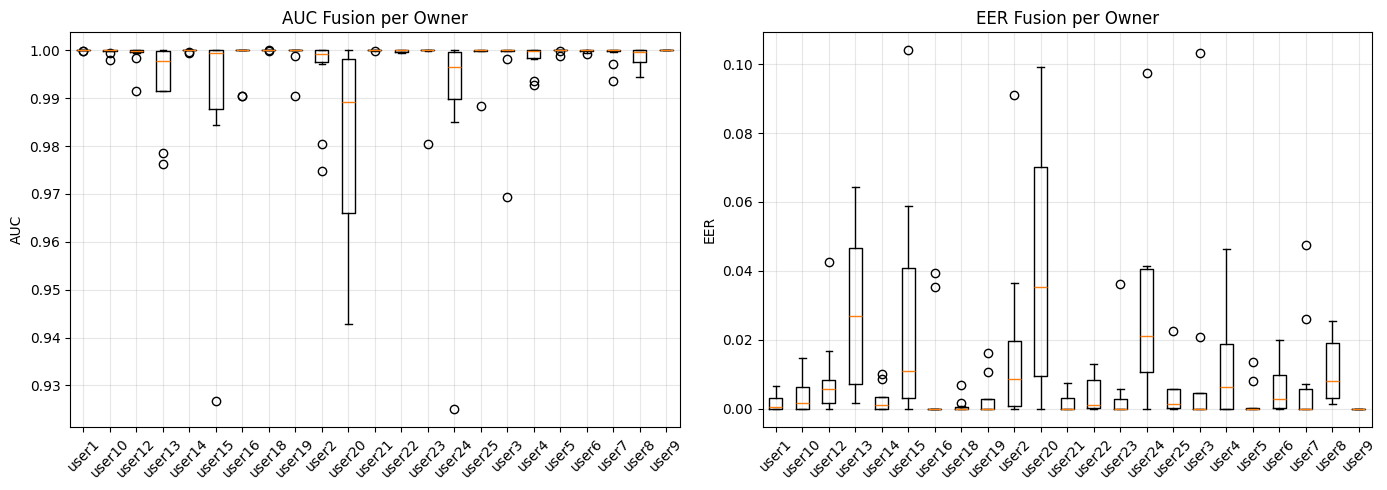

Saved: results/boxplots.png


In [ ]:
# Boxplot AUC fusion per owner
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("results/summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC fusion
data_auc = [df[df["owner_id"] == u]["auc_fusion"].values
            for u in sorted(df["owner_id"].unique())]
axes[0].boxplot(data_auc, labels=sorted(df["owner_id"].unique()))
axes[0].set_title("AUC Fusion per Owner")
axes[0].set_ylabel("AUC")
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

# EER fusion
data_eer = [df[df["owner_id"] == u]["eer_fusion"].values
            for u in sorted(df["owner_id"].unique())]
axes[1].boxplot(data_eer, labels=sorted(df["owner_id"].unique()))
axes[1].set_title("EER Fusion per Owner")
axes[1].set_ylabel("EER")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("results/boxplots.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/boxplots.png")


## §9. Download artifacts

Đóng gói tất cả output (models, exports, results) thành 1 zip và tải về máy.


In [ ]:
# Zip toàn bộ artifacts (chỉ giữ models/, export/, results/)
# [FIXED v4] Bỏ shutil.make_archive — block bên dưới tự zip từng folder.
import os, zipfile

zip_path = "/content/active_auth_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in ["models", "export", "results"]:
        if os.path.isdir(folder):
            for root, _, files in os.walk(folder):
                for f in files:
                    fp = os.path.join(root, f)
                    zf.write(fp, arcname=fp)

print(f"Zip size: {os.path.getsize(zip_path) // 1024} KB")
print(f"Path    : {zip_path}")


Zip size: 407 KB
Path    : /content/active_auth_artifacts.zip


In [ ]:
# Download zip về máy
try:
    from google.colab import files
    files.download("/content/active_auth_artifacts.zip")
except ImportError:
    print("Không phải Colab — tự copy /content/active_auth_artifacts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Hoặc copy vào Google Drive để lưu lâu dài
import shutil
DRIVE_OUT = "/content/drive/MyDrive/active_auth_artifacts.zip"
try:
    shutil.copy("/content/active_auth_artifacts.zip", DRIVE_OUT)
    print(f"Đã copy: {DRIVE_OUT}")
except FileNotFoundError:
    print("Drive chưa mount — chạy lại §2.")


Đã copy: /content/drive/MyDrive/active_auth_artifacts.zip


## §10. Bước tiếp theo

Sau khi training xong:

1. **Convert backbone sang TFLite** để nhúng Android — viết script convert riêng (`PyTorch → ONNX → TFLite` hoặc `ai-edge-torch`).
2. **Nhúng artifacts vào Android app** — đặt vào `app/src/main/assets/`.
3. **Implement RF on-device** (Kotlin) — dùng thư viện `smile-core` hoặc retrain RF từ ONNX runtime.
4. **Triển khai Active Authentication state machine** trên app — EMA trust score + threshold + gesture challenge fallback.

Xem `README.md` trong source code để biết chi tiết về deployment.
